# Korea RIM (Residual Income Model) Valuation **v5** — Phase 2 선형 fade

**v5 변경점**
1. (Cell 5-B) Phase 2 기하 decay(ω) → **선형 fade** 교체: 스프레드가 CAP 종료 시 정확히 0, retention 도 지속가능 수준(g_term/Re)으로 수렴 → 고성장 종목의 RI 폭주·TV 뻥튀기(A019180 Upside 95,793% 사례) 구조적 차단. TV 자동 0.

**v4 변경점**
1. (Cell 2-B) 매출예측 로더 패치 — `updated_at` 버전 선택 + 3중 검증 (구스키마 created_at 버그로 단일 분기 복제되던 문제 차단)
2. (Cell 5-B) Phase 2 `RI 금액 decay` → `ROE 스프레드 decay` 교체 (음수 retention 종목의 ROE 발산 / PV 과대계상 수정)

## Sales-driven DuPont ROE → Ohlson (1995) Residual Income Valuation

### 노트북 흐름 — 인프라 → 개별 진단 → 배치 (FCFF v6 와 동일 패턴)

```
┌─ 1. 인프라 (1회 실행) ─────────────────────────────────────┐
│   Cell 1   경로 자동 감지                                    │
│   Cell 2   Import & 설정 상수                                │
│   Cell 3   DB 연결 & 결과 테이블 초기화                       │
│   Cell 4   시장 파라미터 (Rf / KOSPI / E(Rm))                │
│   Cell 5   KoreaRIMModel 클래스                              │
│   Cell 5-B ★ v5: Phase 2 선형 fade 패치 (TV 자동 0)             │
│   Cell 6   ★ NEW: Excel Export 메서드 주입                  │
└──────────────────────────────────────────────────────────────┘
            ▼
┌─ 2. 개별 종목 진단 ──────────────────────────────────────┐
│   Cell 7   RIM 진단 (단일 종목)                              │
│   Cell 8   ★ NEW: 단일 Ticker → 8-sheet Excel 출력         │
└──────────────────────────────────────────────────────────────┘
            ▼ (개별 검증 OK 시 진행)
┌─ 3. 배치 + 결과 분석 ────────────────────────────────────┐
│   Cell 9   배치 실행 → DB 적재                               │
│   Cell 10  결과 조회                                         │
│   Cell 11  품질 진단                                         │
└──────────────────────────────────────────────────────────────┘
```

### v3 NEW — Excel Export (호영님 요구: .py 파일 분리 X, 노트북 셀 안에 직접)

| 항목 | 내용 |
|---|---|
| 시트 수 | **8개** (FCFF 9개에 해당) |
| 옵션 B 패턴 | Re/BV₀/PV(RI)/PV(TV) 모두 model 결과 직접 입력 → Excel TP = Model TP **자동 일치** |
| 코드 위치 | Cell 6 단일 셀 (약 1,000줄) — 클래스 정의(Cell 5)와 분리 |
| 8-Sheet 구성 | (1)Summary (2)DuPont (3)RI Schedule (4)Moat 6-Tier (5)Beta (6)CoE (7)RIM Valuation (8)Notes |

### v1 → v2 변경 (★ 옵션 A — 지표 추출 함수 통일)

FCFF 모형 (`korea_fcff_dcf_valuation_v6`) 과의 **지표 추출 단계** 일관성 통일.
같은 종목에 대해 두 모형이 같은 tax/Re/Beta 값을 사용하도록 보장.

| # | 변경 항목 | v1 (이전) | v2 (현재) | 이유 |
|---|---|---|---|---|
| 1 | Tax rate 메서드명 | `_estimate_tax_rate` (private) | `estimate_tax_rate` (public) | FCFF 패턴 일관 |
| 2 | Tax rate 로깅 | 없음 | DataQualityReport 추가 | FCFF 와 동일하게 품질 추적 |
| 3 | Re (CAPM) 계산 | `clip(Re, 6%, 18%)` | clip 제거, raw 사용 | FCFF 모형은 clip 없음 → 일관성 |
| 4 | RE_FLOOR / RE_CAP 상수 | 사용 중 | **None (비활성)** | 위 변경에 따른 정리 |
| 5 | 호출 위치 일괄 변경 | `_estimate_tax_rate()` 2곳 | `estimate_tax_rate()` 2곳 | 변경 ①에 따른 정리 |

### v1 그대로 유지 (각 모형의 본질적 차이 — 의도된 것)

| 항목 | FCFF v6 | RIM v2 |
|---|---|---|
| 가치측정 본질 | DCF (FCFF 할인) | RIM (RI 할인) |
| 수익성 지표 | ROIC = NOPAT / IC | ROE = NI / Equity |
| 기회비용 | WACC (전체 자본) | Re (자기자본만) |
| Moat 분류 | 4-tier (Wide/Narrow/Some/No) | **6-tier** (Exceptional/Wide/W-N/Narrow/Some/No) |
| Phase 2 기간 | 5~15년 | **10~30년** (Mauboussin CAP 강조) |
| Persistence | ρ = 0.60 ~ 0.90 | ω = **0.88 ~ 0.99** |
| Phase 1 plateau | 항상 2년 | moat 등급별 2~? 년 |

→ 두 모형이 같은 종목에 대해 **다른 valuation 결과**를 내는 것은 정상 (각 모형의 가정 차이).
   다만 Tax/Re/Beta 같은 **공통 입력값**은 v2 부터 완전 일치.

### 처리 흐름
```
①  korea_fs_data_from_DG  →  과거 IS / BS / CF 분기 데이터
②  korea_revenue_forecast_result → 8분기 매출 예측
③  DuPont 분해 (Sales-driven)
      NPM  = NetIncome / Sales      [OLS slope 또는 median ratio]
      AT   = TTM Sales / Total Assets
      FL   = Total Assets / Equity
      ROE  = NPM × AT × FL          [Phase 1: 2yr + moat plateau]
④  Re   =  Rf(BOK) + β_blume × ERP  ★ v2: clip 제거 (FCFF 일관)
⑤  RI spread AR(1) decay
      Phase 2 (10~30yr) : RI(t) = ω × RI(t-1)   [EVA/moat based ω]
      Phase 3            : TV = RI_last × (1+g) / (Re - g)
⑥  Intrinsic Value  =  BV₀  +  Σ PV(RI_t)  +  PV(TV)
      → 주당가치 = IV / shares_treasury_adj
```

### 학술 근거
- **Ohlson (1995)** *JAR* — Residual Income / Linear Information Model
- **Feltham & Ohlson (1995)** *JAR* — ω (persistence) coefficient
- **Fama & French (1995)** *JF* — Mean reversion of profitability (AR(1))
- **Mauboussin & Johnson (1997)** *FAJ* — Competitive Advantage Period (CAP)
- **Damodaran (2002)** — 3-Stage 구조 및 phase period 지침

### 호영님 5가지 결정사항 (FCFF / RelVal 동일)
1. DataGuide item_code — xlsx 헤더 기반 매핑 35개
2. 매출예측 — `korea_revenue_forecast_result` (indicator=model명, created_at=예측일)
3. KOSPI — FDR/pykrx/yfinance 3단 fallback
4. ERP — Damodaran 한국 7% 기본 / KOSPI geo 10y floor 옵션
5. 결측 처리 — `DataQualityReport` 추적 → `korea_valuation_quality_log` 저장

### v1 → v2 사용자 영향 예측
- **같은 종목**의 RIM 결과가 v1 대비 약간 변동될 수 있음 (Re clip 제거 효과)
- Beta 가 매우 낮거나 ERP 가 낮은 종목: v1 에선 Re=6% 로 floor → v2 에선 raw (ex. 5%)
- Beta 가 매우 높은 종목: v1 에선 Re=18% 로 cap → v2 에선 raw (ex. 20%)
- 일반 종목: 거의 영향 없음 (Re 가 [6%, 18%] 안에 자연스럽게 위치)

### 저장
- 결과: `korea_rim_valuation` (PK: ticker, date, year_label)
- 품질: `korea_valuation_quality_log` (model='RIM')


## Cell 1 · 경로 자동 감지

In [21]:
import sys, os, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

_CANDIDATE_ROOTS = [
    r"C:\Users\Hoyoung_Park\PyCharmMiscProject\stock_forecast",
    r"C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy",
]

def _setup_path() -> str:
    try:
        start = Path(__file__).resolve().parent
    except NameError:
        start = Path.cwd()
    for p in [start] + list(start.parents):
        if (p / "DATA").is_dir():
            root = str(p)
            if root not in sys.path:
                sys.path.insert(0, root)
            print(f"[PATH] root 자동 감지 : {root}")
            return root
    for cand in _CANDIDATE_ROOTS:
        if os.path.isdir(cand) and os.path.isdir(os.path.join(cand, "DATA")):
            if cand not in sys.path:
                sys.path.insert(0, cand)
            print(f"[PATH] root 후보 경로 : {cand}")
            return cand
    raise EnvironmentError("DATA 폴더를 찾을 수 없습니다.")

_ROOT = _setup_path()
print(f"[확인] 프로젝트 루트 : {_ROOT}")


[PATH] root 자동 감지 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy
[확인] 프로젝트 루트 : C:\Users\82108\OneDrive\바탕 화면\investment\investment_strategy


## Cell 2 · Import & 설정 상수

> **여기만 수정하면 됩니다**:
> - `TICKER_START / TICKER_END / SKIP_DONE`
> - `ERP_METHOD`
> - `MIN_REVENUE_QUARTERS`, `PHASE1_EXTRA_YR`


In [22]:
import gc, math, time, traceback
from datetime import datetime, date, timedelta
from typing import Optional, Dict, Any, List, Tuple

import numpy as np
import pandas as pd
import pymysql
from scipy import stats
from IPython.display import display
import matplotlib
matplotlib.rcParams["axes.unicode_minus"] = False
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sqlalchemy import text

from DATA.config import get_db_info, get_engine
from DATA.KEYS import KEYS
from DATA.korea_valuation_helpers import (
    setup_project_path, to_dg_ticker, to_price_ticker, get_pymysql_conn,
    DG_ITEM_CODES,
    load_korea_financials_wide, load_korea_revenue_forecast,
    load_korea_marketcap_latest, load_korea_price_series, load_current_price,
    load_kospi_series, get_risk_free_rate, compute_beta_10y,
    estimate_market_return, get_universe_with_min_history,
    DataQualityReport, save_quality_report_to_db,
)

In [23]:

def log(tag, msg):
    ts = datetime.now().strftime("%H:%M:%S")
    print(f"[{ts}][{tag}] {msg}", flush=True)

# ══════════════════════════════════════════════════════════════════
#  DB 테이블
# ══════════════════════════════════════════════════════════════════
TABLE_FS        = "korea_fs_data_from_DG"
TABLE_FORECAST  = "korea_revenue_forecast_result"
TABLE_PRICE     = "KSE_Price"
TABLE_MARKETCAP = "ks_listed_company_daily_marketcap"
TABLE_RESULT    = "korea_rim_valuation"
TABLE_QUALITY   = "korea_valuation_quality_log"

# ══════════════════════════════════════════════════════════════════
#  모델 파라미터
# ══════════════════════════════════════════════════════════════════
FORECAST_HORIZON    = 8       # 예측 분기 수 (= 2년)
MIN_HISTORY         = 12      # DuPont OLS 최소 분기 수
MIN_REVENUE_QUARTERS = 24     # universe 필터: 최소 6년 매출 보유

# OLS 기준 (ratio 회귀가 본질적으로 noisy → FCFF 보다 완화)
OLS_MIN_R2          = 0.3
OLS_MIN_SAMPLES     = 12
WINSORIZE_LIMITS    = (0.05, 0.95)

# ── Terminal / Phase 2 ─────────────────────────────────────────
GDP_GROWTH          = 0.04   # 한국 장기 GDP
TV_RE_GAP           = 0.010   # TV: g = Re - 1% (US v11은 0.75%)
RETENTION_FLOOR     = -0.50   # 음수 허용 (buyback > NI 예외 케이스)
BV_RETENTION_CAP    = 0.75

# ── Phase 1 기간: moat 등급별 plateau ──────────────────────────
PHASE1_BASE_YR  = 2   # Sales forecast 실제 예측 2년 (고정)
PHASE1_EXTRA_YR = {
    "Exceptional moat":  5,   # 총 7yr
    "Wide moat":         4,   # 총 6yr
    "Wide-Narrow moat":  3,   # 총 5yr
    "Narrow moat":       2,   # 총 4yr
    "Some moat":         1,   # 총 3yr
    "No moat":           0,   # 총 2yr
    "Unknown (fallback)":1,
}
PHASE1_YR_BY_MOAT = {g: PHASE1_BASE_YR + e for g, e in PHASE1_EXTRA_YR.items()}

# ── Phase 1 ROE 안정장치 ───────────────────────────────────────
PHASE1_ROE_FLOOR_RATIO   = 0.80    # 과거 TTM ROE 대비 floor 비율
PHASE1_ROE_CEILING_RATIO = 2.50

# ── WACC / Re ──────────────────────────────────────────────────
ERP_METHOD        = "damodaran_floor"   # 'damodaran_floor' | 'kospi_geo_10y'
DAMODARAN_ERP_KR  = 0.07
GEO_FLOOR         = 0.07
RF_FALLBACK       = 0.035
# ★ v2 옵션 A 통일: Re clip 제거 (FCFF 모형과 일관)
#   기존 v1: RE_FLOOR=0.06, RE_CAP=0.18 으로 Re 를 강제로 [6%, 18%] 로 clip
#   변경 v2: clip 제거 → Beta·ERP 가 raw 그대로 Re 에 반영 (FCFF 패턴)
#   상수 자체는 호환성을 위해 유지하되, KoreaRIMModel.load_re 에서 사용 안함.
RE_FLOOR          = None    # ★ v2 옵션 A: 비활성화 (FCFF 와 일관)
RE_CAP            = None    # ★ v2 옵션 A: 비활성화 (FCFF 와 일관)
RD_DEFAULT        = 0.045

# ── 단위 변환 ──────────────────────────────────────────────────
FS_UNIT_MULTIPLIER        = 1_000        # 천원 → 원
MARKETCAP_UNIT_MULTIPLIER = 1_000_000    # 백만원 → 원

# ── 재무 항목 키 ───────────────────────────────────────────────
DEBT_KEYS = ["short_term_debt", "current_lt_debt", "bonds",
             "long_term_debt", "lease_liab"]
CASH_KEYS = ["cash", "short_term_invest"]

# ── 배치 범위 ──────────────────────────────────────────────────
TICKER_START = 0
TICKER_END   = 9999
SKIP_DONE    = False

CHECKPOINT_DIR = "_korea_rim_checkpoint"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
DONE_PATH = os.path.join(CHECKPOINT_DIR, "done_tickers.txt")
FAIL_PATH = os.path.join(CHECKPOINT_DIR, "failed_tickers.txt")

db_info = get_db_info()
engine  = get_engine(db_info)

print("[OK] Import 완료")
print(f"[설정] FORECAST_HORIZON={FORECAST_HORIZON}Q  ERP_METHOD={ERP_METHOD}")
print(f"[설정] GDP_GROWTH={GDP_GROWTH}  TV_RE_GAP={TV_RE_GAP}  Re clip: ★ v2 비활성 (FCFF 일관)")
print(f"[설정] Phase1 plateau by moat (기본 2yr + moat 연장):")
for k, v in PHASE1_EXTRA_YR.items():
    print(f"        {k:<22s}: {PHASE1_BASE_YR}+{v} = {PHASE1_BASE_YR+v}yr")

[OK] Import 완료
[설정] FORECAST_HORIZON=8Q  ERP_METHOD=damodaran_floor
[설정] GDP_GROWTH=0.04  TV_RE_GAP=0.01  Re clip: ★ v2 비활성 (FCFF 일관)
[설정] Phase1 plateau by moat (기본 2yr + moat 연장):
        Exceptional moat      : 2+5 = 7yr
        Wide moat             : 2+4 = 6yr
        Wide-Narrow moat      : 2+3 = 5yr
        Narrow moat           : 2+2 = 4yr
        Some moat             : 2+1 = 3yr
        No moat               : 2+0 = 2yr
        Unknown (fallback)    : 2+1 = 3yr


In [24]:
# ═══════════════════════════════════════════════════════════════
#  PATCH 셀 · load_korea_revenue_forecast 교체
#  (구스키마 created_at 버그 → 매출 forecast 상수 복제 문제 수정)
#
#  ▸ 붙여넣을 위치 : korea_fcff_dcf_valuation_v7.ipynb 의
#                    import 셀(DATA.korea_valuation_helpers import) "바로 다음".
#                    KoreaDCFModel 실행(Cell 9/10) 전이면 어디든 OK.
#  ▸ 원리          : 노트북 전역의 load_korea_revenue_forecast 이름을
#                    아래 수정판으로 재바인딩 → KoreaDCFModel.load_sales 가
#                    호출 시점에 이 패치판을 사용.
#  ▸ 주의          : import 셀을 다시 실행하면 패치가 풀리므로,
#                    import 셀 재실행 후에는 이 셀도 재실행할 것.
#
#  ▸ 수정 내용 (korea_revenue_analysis_notebook_v3 의 fetch_forecast 와 동일 원리)
#    1) 버전 식별: MAX(created_at) → MAX(updated_at) (자동 감지, 없으면 created_at)
#       - 구스키마 UNIQUE KEY(date,ticker,indicator) 에서는 재예측 시
#         겹치는 분기의 created_at 이 갱신되지 않아 '새로 생긴 분기 1개'만
#         최신 버전으로 잡히는 문제가 있었음 (예: A031330 → 2028Q1 한 분기).
#    2) 같은 분기 중복 시 가장 최근 갱신분만 사용.
#    3) 검증 추가 — 아래 셋 중 하나라도 걸리면 ValueError 로 즉시 차단
#       (잘못된 valuation 이 DB 에 저장되는 것을 막기 위함):
#       a. 분기 수 < horizon
#       b. 분기 불연속 (중간 분기 누락)
#       c. 전 분기 동일값 (상수 시계열 — 이번 버그의 증상)
# ═══════════════════════════════════════════════════════════════
from sqlalchemy import text as _sa_text

_FC_MODEL_PRIORITY = ("Ensemble", "SARIMA", "ETS", "Theta")
_FC_RECENCY_CACHE: dict = {}


def _fc_recency_col(table_name: str) -> str:
    """updated_at 컬럼이 있으면 그것을, 없으면 created_at 을 버전 기준으로 사용."""
    if table_name in _FC_RECENCY_CACHE:
        return _FC_RECENCY_CACHE[table_name]
    sql = ("SELECT COLUMN_NAME FROM information_schema.COLUMNS "
           "WHERE TABLE_SCHEMA = :db AND TABLE_NAME = :tbl")
    with engine.connect() as conn:
        cols = {r[0].lower() for r in conn.execute(
            _sa_text(sql), {"db": db_info["database"], "tbl": table_name}
        ).fetchall()}
    rc = "updated_at" if "updated_at" in cols else "created_at"
    _FC_RECENCY_CACHE[table_name] = rc
    if rc == "created_at":
        log("PATCH", f"[주의] {table_name} 에 updated_at 없음 → created_at 기준. "
                     "구스키마면 일부 종목 분기 누락 가능 — updated_at 추가 권장.")
    return rc


def load_korea_revenue_forecast(ticker: str,
                                db_info: dict,
                                table_name: str = "korea_revenue_forecast_result",
                                horizon: int = 8):
    """[PATCHED v7-fix] 최신 '실행 버전' 전체 분기를 안전하게 로드.

    Returns
    -------
    (pd.Series, str, str)
        forecast : 천원 단위, index=분기 date (호출측에서 ×1000 변환)
        model    : 사용된 indicator (Ensemble 우선)
        run_date : 예측 실행 버전 날짜 (YYYY-MM-DD)
    """
    rc = _fc_recency_col(table_name)

    df, used_model, run_date = None, "", None
    for model in _FC_MODEL_PRIORITY:
        # indicator 가 'Ensemble' 형태든 '매출액(천원)_Ensemble' 형태든 모두 매칭
        with engine.connect() as conn:
            row = conn.execute(_sa_text(
                f"SELECT MAX(DATE({rc})) FROM {table_name} "
                f"WHERE ticker = :t AND (indicator = :m OR indicator LIKE :ml)"
            ), {"t": ticker, "m": model, "ml": f"%\\_{model}"}).fetchone()
        if row is None or row[0] is None:
            continue
        run_date = str(row[0])
        cand = pd.read_sql(_sa_text(
            f"SELECT date, value, {rc} AS run_ts FROM {table_name} "
            f"WHERE ticker = :t AND (indicator = :m OR indicator LIKE :ml) "
            f"  AND DATE({rc}) = :fd "
            f"ORDER BY date"
        ), engine, params={"t": ticker, "m": model,
                           "ml": f"%\\_{model}", "fd": run_date})
        if not cand.empty:
            df, used_model = cand, model
            break

    if df is None:
        return pd.Series(dtype=float), "", None

    df["date"]   = pd.to_datetime(df["date"])
    df["run_ts"] = pd.to_datetime(df["run_ts"])
    df = (df.sort_values(["date", "run_ts"])
            .drop_duplicates(subset=["date"], keep="last"))
    fc = df.set_index("date")["value"].astype(float).sort_index()

    # ── 검증 a: 분기 수 ───────────────────────────────────────
    if len(fc) < horizon:
        raise ValueError(
            f"[{ticker}] forecast 분기 {len(fc)}개 < horizon {horizon} "
            f"(version={rc} {run_date}, indicator={used_model}). "
            f"구스키마 created_at 잔존 가능성 — 해당 종목 재예측 또는 "
            f"테이블 updated_at 마이그레이션 필요."
        )
    fc = fc.iloc[:horizon]

    # ── 검증 b: 분기 연속성 ──────────────────────────────────
    per = fc.index.to_period("Q")
    gaps = (per[1:].astype("int64") - per[:-1].astype("int64"))
    if (gaps != 1).any():
        bad = [str(per[i + 1]) for i, g in enumerate(gaps) if g != 1]
        raise ValueError(
            f"[{ticker}] forecast 분기 불연속: {bad} "
            f"(version={rc} {run_date}). 해당 종목 재예측 필요."
        )

    # ── 검증 c: 상수 시계열 (이번 버그의 증상) ────────────────
    if fc.nunique() == 1:
        raise ValueError(
            f"[{ticker}] forecast {horizon}개 분기가 모두 동일값"
            f"({fc.iloc[0]:,.0f}천원) — 단일 분기 복제 의심. "
            f"(version={rc} {run_date}). 해당 종목 재예측 필요."
        )

    return fc, used_model, run_date


log("PATCH", "load_korea_revenue_forecast → updated_at 버전 선택 + 3중 검증 패치 적용 완료")

[18:34:40][PATCH] load_korea_revenue_forecast → updated_at 버전 선택 + 3중 검증 패치 적용 완료


## Cell 3 · DB 연결 & 결과 테이블 초기화

결과 테이블 `korea_rim_valuation`:
- PK = (ticker, date, year_label) — 같은 종목+평가일자에서 Ph1 year1/year2/... + Ph2 year1/year2/... + TV row 각각 저장
- 평가일자(date)가 달라지면 별도 row → 시계열 추적 가능


In [25]:
CREATE_SQL = f"""
CREATE TABLE IF NOT EXISTS `{TABLE_RESULT}` (
  `id`              BIGINT      NOT NULL AUTO_INCREMENT,
  `date`            DATE        NOT NULL COMMENT '평가 실행일',
  `ticker`          VARCHAR(20) NOT NULL,
  `year_label`      VARCHAR(10)          COMMENT '2026 / Ph2-Y3 / TV',
  `phase`           VARCHAR(10)          COMMENT 'ph1 / ph1e / ph2 / tv',
  `sales_forecast`  DOUBLE               COMMENT '연간 매출 (원)',
  `npm_forecast`    DOUBLE,
  `asset_turnover`  DOUBLE,
  `fin_leverage`    DOUBLE,
  `roe_forecast`    DOUBLE,
  `re`              DOUBLE               COMMENT 'Cost of Equity',
  `ri_spread`       DOUBLE               COMMENT 'ROE - Re',
  `bv_start`        DOUBLE               COMMENT 'BV 또는 IC (원)',
  `ri`              DOUBLE               COMMENT 'Residual Income (원)',
  `pv_ri`           DOUBLE               COMMENT 'PV of RI',
  `moat_label`      VARCHAR(30),
  `rho`             DOUBLE               COMMENT 'AR(1) omega',
  `n_phase2`        INT,
  `g_terminal`      DOUBLE,
  `pv_all_ri`       DOUBLE,
  `terminal_value`  DOUBLE,
  `intrinsic_value` DOUBLE,
  `current_price`   DOUBLE,
  `upside_pct`      DOUBLE,
  `target_price`    DOUBLE,
  `beta_raw`        DOUBLE,
  `beta_blume`      DOUBLE,
  `bv_source`       VARCHAR(10)          COMMENT 'Equity / IC_fallback',
  `revenue_quarters`INT,
  `forecast_model`  VARCHAR(20),
  `forecast_date`   DATE,
  `created_at`      DATETIME    DEFAULT CURRENT_TIMESTAMP,
  PRIMARY KEY (`id`),
  UNIQUE KEY uq_main (`ticker`, `date`, `year_label`),
  INDEX idx_ticker (`ticker`),
  INDEX idx_date   (`date`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4
"""

conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(CREATE_SQL)
    conn.commit()
    log("DB", f"테이블 준비 완료: {TABLE_RESULT}")
finally:
    conn.close()

try:
    with engine.connect() as c:
        c.execute(text("SELECT 1"))
    log("DB", f"연결 성공 host={db_info.get('host')} port={db_info.get('port')}")
except Exception as e:
    log("DB", f"연결 실패: {e}")

# Universe 조회
universe_df = get_universe_with_min_history(
    db_info, min_quarters=MIN_REVENUE_QUARTERS, require_consecutive=False)
KOREA_TICKER_LIST = universe_df["ticker"].tolist()
print(f"\n[Universe] 매출 ≥{MIN_REVENUE_QUARTERS}분기 종목: {len(KOREA_TICKER_LIST):,}개")


[18:34:43][DB] 테이블 준비 완료: korea_rim_valuation
[18:34:43][DB] 연결 성공 host=192.168.0.230 port=3307

[Universe] 매출 ≥24분기 종목: 1,277개


## Cell 4 · 시장 파라미터 — Rf, KOSPI, E(Rm)

FCFF/RelVal 노트북과 동일 로직. KOSPI 로더는 3단 fallback (FDR → pykrx → yfinance).


In [26]:
# 1. Risk-free (BOK 10Y 국고채)
RF, RF_SOURCE = get_risk_free_rate(KEYS["BOK"], fallback_rate=RF_FALLBACK)
log("MKT", f"Rf = {RF:.4%}  (source: {RF_SOURCE})")

# 2. KOSPI (helpers의 3단 fallback 로더 사용)
KOSPI_PX = load_kospi_series(
    start_date=(datetime.today() - timedelta(days=365*12)).strftime("%Y-%m-%d"))
log("MKT", f"KOSPI {len(KOSPI_PX):,}거래일  "
            f"({KOSPI_PX.index.min().date()} ~ {KOSPI_PX.index.max().date()})")

# 3. E(Rm)
mkt = estimate_market_return(
    method=ERP_METHOD, rf=RF, kospi_series=KOSPI_PX,
    years=10, damodaran_erp_kr=DAMODARAN_ERP_KR, geo_floor=GEO_FLOOR)
E_RM = mkt["e_rm"]
ERP  = mkt["erp"]
log("MKT", f"E(Rm) = {E_RM:.4%}  ERP = {ERP:.4%}  ({mkt['note']})")

print()
print("=" * 60)
print(f"  Rf     = {RF:>7.3%}")
print(f"  ERP    = {ERP:>7.3%}")
print(f"  E(Rm)  = {E_RM:>7.3%}")
print(f"  Re clip = ★ v2 비활성 (FCFF 와 일관 — raw Re 사용)")
print("=" * 60)


[18:34:52][MKT] Rf = 4.2610%  (source: BOK_2026-07-31)
[KOSPI] try source=fdr (2014-08-03 ~ 2026-07-31) ... FAIL (FDR 실패 (재시도 3회): LOGOUT)
[KOSPI] try source=pykrx (2014-08-03 ~ 2026-07-31) ... FAIL ('지수명')
[KOSPI] try source=yfinance (2014-08-03 ~ 2026-07-31) ... OK  2,937거래일
[18:35:00][MKT] KOSPI 2,937거래일  (2014-08-04 ~ 2026-07-30)
[18:35:00][MKT] E(Rm) = 11.2610%  ERP = 7.0000%  (Damodaran 한국 ERP 7.0% 적용)

  Rf     =  4.261%
  ERP    =  7.000%
  E(Rm)  = 11.261%
  Re clip = ★ v2 비활성 (FCFF 와 일관 — raw Re 사용)


## Cell 5 · KoreaRIMModel 클래스

US v11 RIMModel 의 한국화. 핵심 로직 (Ohlson 1995, 6-Tier moat, AR(1) decay) 동일, 데이터 소스만 DataGuide DB로 교체.


[OK] KoreaRIMModel 정의 완료

[테스트] A204620
[18:35:01][A204620] Sales actual=26Q forecast=8Q (Ensemble)
[18:35:01][A204620] FS wide shape=(67, 35)
[18:35:03][A204620] Re=9.2029%  β_raw=0.561 β_blume=0.706  Rf=4.261% ERP=7.000%
[18:35:03][A204620] DuPont  NPM=0.0396(median)  AT=0.449(TTM)  FL=1.44
[18:35:08][A204620] EVA: ROIC=118.27% WACC=9.20% spread=+109.07% n_pos=11/20  ROE-Re=+14.5%
[18:35:08][A204620] Retention=0.980  payout=0.000
[18:35:08][A204620] Retention=0.980  payout=0.000
[18:35:08][A204620] RI path: Ph1=6yr Ph2=28yr  RI_last=0.02조  [Wide moat ω=0.98 PVf=8.33]
[18:35:10][A204620] RIM  BV=0.15조 PV(RI)=0.24조 PV(TV)=0.09조 IV=0.48조  TP=6,845원 CP=4,230원 Up=+61.8%  [Wide moat]

  status=ok  moat=Wide moat  omega=0.980
  TP=6,845원  CP=4,230원  Upside=+61.8%  BV src=Equity

────────────────────────────────────────────────────────────
데이터 품질 리포트:
────────────────────────────────────────────────────────────
[A204620]  ok=11  fallback_median=1  fallback_zero=0  missing=0  warning=0  min_R

,field,status,n_obs,value,r2,note
0,revenue_actual,ok,26,NaN,NaN,
1,revenue_forecast,ok,8,NaN,NaN,model=Ensemble
2,fs_core,ok,26,NaN,NaN,
3,beta,ok,2447,7.059891e-01,0.059090,β_raw=0.561
4,npm,fallback_median,26,3.957309e-02,0.256919,R²=0.26 → median
5,asset_turnover,ok,23,4.487469e-01,NaN,
6,financial_leverage,ok,40,1.440864e+00,NaN,
7,tax_rate,ok,16,2.082980e-01,NaN,
8,tax_rate,ok,16,2.082980e-01,NaN,
9,bv0,ok,0,1.547904e+11,NaN,


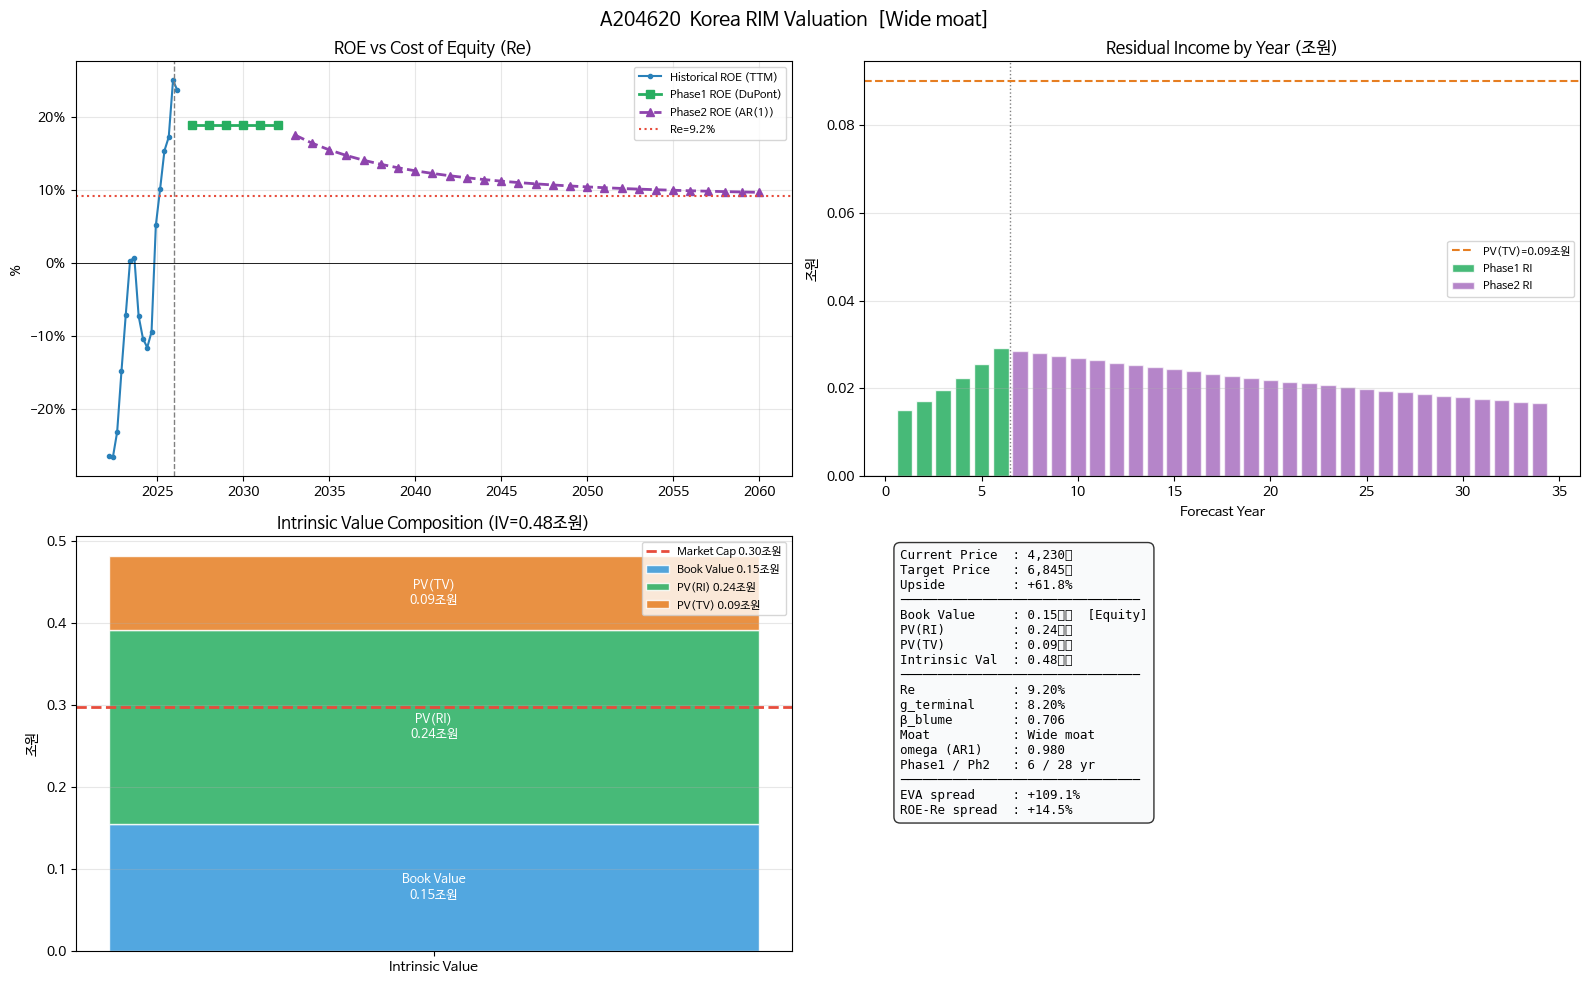

In [27]:
# ═══════════════════════════════════════════════════════════════
#  KoreaRIMModel — Ohlson (1995) Residual Income Valuation
# ═══════════════════════════════════════════════════════════════

class KoreaRIMModel:
    """
    한국 주식 RIM 평가 모델.

    공식:
        IV = BV_0 + Σ RI_t / (1+Re)^t + PV(TV)
        RI_t = (ROE_t - Re) × BV_{t-1}
        BV_t = BV_{t-1} × (1 + ROE_t × retention)  [with Re floor]

    Phase 1: DuPont 기반 ROE forecast (2yr 실제 + moat plateau 확장)
    Phase 2: AR(1) decay  RI(t) = ω × RI(t-1)   [5~30yr moat 등급별]
    Phase 3: TV = RI_last × (1+g) / (Re - g)

    US v11과 동일한 6-Tier moat 분류 + OR 로직 + n_pos 페널티.
    """

    def __init__(self, ticker, engine, db_info, rf, e_rm, kospi_series,
                 forecast_horizon=FORECAST_HORIZON,
                 min_history=MIN_HISTORY,
                 gdp_growth=GDP_GROWTH,
                 verbose=False):
        self.ticker_dg    = to_dg_ticker(ticker)
        self.ticker_price = to_price_ticker(ticker)
        self.engine       = engine
        self.db_info      = db_info
        self.rf           = rf
        self.e_rm         = e_rm
        self.erp          = e_rm - rf
        self.kospi        = kospi_series
        self.horizon      = forecast_horizon
        self.min_history  = min_history
        self.gdp_growth   = gdp_growth
        self.verbose      = verbose

        self._sales_actual   = None
        self._sales_forecast = None
        self._used_model     = ""
        self._forecast_date  = None
        self._fs_wide        = None
        self._re             = None
        self._eva_cache      = None
        self._beta_info      = None

        self._using_ic    = False
        self._n_phase1    = 2
        self._bv_source   = "Equity"
        self.result_df    = None
        self.valuation    = None

        self.report = DataQualityReport(ticker=self.ticker_dg)

    # ─────────────────────────────────────────────────────────
    # Utility
    # ─────────────────────────────────────────────────────────
    @staticmethod
    def _winsorize(s, limits=WINSORIZE_LIMITS):
        s = s.dropna()
        if len(s) < 4: return s
        lo, hi = s.quantile(limits[0]), s.quantile(limits[1])
        return s.clip(lo, hi)

    @staticmethod
    def _ols_ratio(x, y):
        mask = x.notna() & y.notna() & (x != 0)
        if mask.sum() < OLS_MIN_SAMPLES:
            return np.nan, -1.0, int(mask.sum())
        slope, _, r, _, _ = stats.linregress(x[mask], y[mask])
        return float(slope), float(r**2), int(mask.sum())

    @staticmethod
    def _n(val):
        if val is None: return None
        try:
            f = float(val)
            return None if (np.isnan(f) or np.isinf(f)) else f
        except (TypeError, ValueError):
            return val

    # ─────────────────────────────────────────────────────────
    # 1. Data Loading
    # ─────────────────────────────────────────────────────────
    def load_sales(self):
        wide = load_korea_financials_wide(
            self.ticker_dg, self.db_info, table_name=TABLE_FS,
            item_keys=["revenue"], fillna_zero=False)
        actual = wide["revenue"].dropna() * FS_UNIT_MULTIPLIER
        if actual.empty or len(actual) < MIN_REVENUE_QUARTERS:
            self.report.add("revenue_actual", "missing", n_obs=len(actual),
                            note=f"actual {len(actual)}Q < {MIN_REVENUE_QUARTERS}")
            raise ValueError(
                f"[{self.ticker_dg}] 매출 actual 부족 ({len(actual)}Q < {MIN_REVENUE_QUARTERS}Q)")
        self.report.add("revenue_actual", "ok", n_obs=len(actual))

        forecast, model_name, ca = load_korea_revenue_forecast(
            self.ticker_dg, self.db_info, table_name=TABLE_FORECAST,
            horizon=self.horizon)
        if forecast.empty:
            self.report.add("revenue_forecast", "missing", n_obs=0,
                            note="korea_revenue_forecast_result 없음")
            raise ValueError(f"[{self.ticker_dg}] 매출 forecast 없음")
        forecast = forecast * FS_UNIT_MULTIPLIER
        self.report.add("revenue_forecast", "ok", n_obs=len(forecast),
                        note=f"model={model_name}")

        self._sales_actual   = actual
        self._sales_forecast = forecast.iloc[:self.horizon]
        self._used_model     = model_name
        self._forecast_date  = ca

        if self.verbose:
            log(self.ticker_dg,
                f"Sales actual={len(actual)}Q forecast={len(self._sales_forecast)}Q "
                f"({model_name})")
        return self

    def load_financials(self):
        wide = load_korea_financials_wide(
            self.ticker_dg, self.db_info, table_name=TABLE_FS,
            item_keys=None, fillna_zero=False)
        if wide.empty:
            raise ValueError(f"[{self.ticker_dg}] FS 데이터 없음")

        non_share = [c for c in wide.columns
                     if c not in ("shares_treasury_adj", "shares_common")]
        wide[non_share] = wide[non_share] * FS_UNIT_MULTIPLIER

        # 핵심항목 검증
        missing_core = []
        if "revenue" not in wide.columns or wide["revenue"].dropna().empty:
            missing_core.append("revenue")
        if "net_income" not in wide.columns or wide["net_income"].dropna().empty:
            missing_core.append("net_income")
        if "total_equity" not in wide.columns or wide["total_equity"].dropna().empty:
            missing_core.append("total_equity")
        if missing_core:
            for k in missing_core:
                self.report.add(k, "missing", n_obs=0)
            raise ValueError(f"[{self.ticker_dg}] 핵심 항목 결측: {missing_core}")

        self.report.add("fs_core", "ok",
                        n_obs=int(wide[["revenue","net_income","total_equity"]]
                                  .notna().all(axis=1).sum()))
        self._fs_wide = wide
        if self.verbose:
            log(self.ticker_dg, f"FS wide shape={wide.shape}")
        return self

    # ─────────────────────────────────────────────────────────
    # 2. Re (Cost of Equity) — 자체 베타 10y + CAPM
    # ─────────────────────────────────────────────────────────
    def load_re(self):
        """β_blume = 0.67×|β| + 0.33  →  Re = Rf + β_blume × ERP

        ★ v2 옵션 A: clip(Re, RE_FLOOR, RE_CAP) 제거 — FCFF 모형과 일관.
           Beta·ERP 가 raw 그대로 Re 에 반영됨.
        """
        info = compute_beta_10y(
            self.ticker_dg, self.db_info, kospi_series=self.kospi,
            years=10, min_obs=750)
        self._beta_info = info

        if np.isnan(info["beta_raw"]):
            beta_blume = 1.0
            self.report.add("beta", "fallback_median", n_obs=info["n_obs"],
                            value=beta_blume, note="베타 계산 실패 → 1.0")
        else:
            beta_blume = info["beta_blume"]
            self.report.add("beta", "ok", n_obs=info["n_obs"],
                            value=beta_blume, r2=info["r_squared"],
                            note=f"β_raw={info['beta_raw']:.3f}")

        # ★ v2 옵션 A: Re clip 제거 (FCFF 와 동일하게 raw 사용)
        re = float(self.rf + beta_blume * self.erp)
        self._re = re

        if self.verbose:
            log(self.ticker_dg,
                f"Re={re:.4%}  β_raw={info.get('beta_raw', np.nan):.3f} "
                f"β_blume={beta_blume:.3f}  Rf={self.rf:.3%} ERP={self.erp:.3%}")
        return self

    # ─────────────────────────────────────────────────────────
    # 3. 보조 함수: IC / TTM ROE / Retention / Tax
    # ─────────────────────────────────────────────────────────
    def _estimate_ic(self):
        """
        Invested Capital = Equity + Total Debt
        음수 BV 기업(적자 누적 또는 대량 자사주매입) 처리용.
        모든 부채가 없으면 totalAssets × 0.4 fallback.
        """
        wide = self._fs_wide.sort_index()
        last = wide.iloc[-1]

        eq = last.get("total_equity", 0) or 0
        td = 0.0
        for k in DEBT_KEYS:
            if k in wide.columns:
                v = last.get(k, 0)
                if pd.notna(v):
                    td += float(v)
        ic = float(eq) + td
        if ic <= 0:
            ta = last.get("total_assets", 0)
            ic = float(ta) * 0.40 if pd.notna(ta) and ta > 0 else 1e11
        return max(ic, 1e10)  # 최소 100억

    def _get_historical_roe_ttm(self):
        """최근 TTM ROE 계산 (DuPont blend용)"""
        try:
            wide = self._fs_wide.sort_index()
            if "net_income" not in wide.columns or "total_equity" not in wide.columns:
                return np.nan
            df = wide[["net_income", "total_equity"]].dropna()
            df = df[df["total_equity"] > 0]
            if len(df) < 4:
                return np.nan
            ni_ttm = float(df["net_income"].iloc[-4:].sum())
            eq_avg = float(df["total_equity"].iloc[-4:].mean())
            return ni_ttm / eq_avg if eq_avg > 0 else np.nan
        except Exception:
            return np.nan

    def estimate_tax_rate(self):
        """실효세율 (한국 법정세율 22% fallback) — FCFF 모형과 일관 (★ v2 옵션 A)."""
        wide = self._fs_wide
        if "pretax_income" not in wide.columns or "tax_expense" not in wide.columns:
            self.report.add("tax_rate", "fallback_zero", n_obs=0,
                            value=0.22, note="컬럼 누락 → 법정세율 22%")
            return 0.22
        df = wide[["pretax_income", "tax_expense"]].dropna()
        df = df[df["pretax_income"] > 0]
        if df.empty:
            self.report.add("tax_rate", "fallback_zero", n_obs=0,
                            value=0.22, note="법정세율 22% fallback")
            return 0.22
        rates = (df["tax_expense"] / df["pretax_income"]).clip(0, 0.40)
        med = float(rates.median())
        self.report.add("tax_rate", "ok", n_obs=len(rates), value=med)
        return med

    def estimate_retention(self):
        """
        실질 이익유보율 = 1 - 배당성향.
        한국 기업은 buyback 데이터 신뢰성 낮음 → 배당(dividends_paid)만 사용.
        Clean Surplus 역산 fallback (NI - ΔEquity).
        """
        wide = self._fs_wide.sort_index()
        if "net_income" not in wide.columns:
            self.report.add("retention", "fallback_zero", value=0.70,
                            note="net_income 없음")
            return 0.70
        ni = wide["net_income"]
        if (ni > 0).sum() == 0:
            self.report.add("retention", "fallback_zero", value=0.70,
                            note="NI 양수 분기 0")
            return 0.70

        div = None
        # 방법 1: dividends_paid 직접 사용
        if "dividends_paid" in wide.columns:
            d = wide["dividends_paid"].abs()
            if (d > 0).sum() >= 4:
                div = d

        # 방법 2: Clean Surplus 역산 (NI - ΔEquity)
        if div is None and "total_equity" in wide.columns:
            eq = wide["total_equity"]
            delta_eq = eq.diff()
            implied = (ni - delta_eq).clip(lower=0)
            if (implied > 0).sum() >= 4:
                div = implied

        if div is None:
            self.report.add("retention", "fallback_zero", value=0.70,
                            note="배당/clean surplus 모두 실패")
            return 0.70

        payout = (div / ni.abs()).replace([np.inf, -np.inf], np.nan)
        po = payout.iloc[-8:].dropna()
        if po.empty:
            po = payout.dropna()
        if po.empty:
            self.report.add("retention", "fallback_zero", value=0.70)
            return 0.70

        payout_med = float(po.clip(0, 3.0).median())
        retention = float(np.clip(1.0 - payout_med, RETENTION_FLOOR, 0.98))

        self.report.add("retention", "ok", n_obs=len(po), value=retention,
                        note=f"payout_med={payout_med:.2%}")
        if self.verbose:
            log(self.ticker_dg, f"Retention={retention:.3f}  payout={payout_med:.3f}")
        return retention

    # ─────────────────────────────────────────────────────────
    # 4. DuPont 계수 추정
    # ─────────────────────────────────────────────────────────
    def estimate_dupont_coefs(self):
        """NPM (OLS → median), AT (TTM), FL (median)"""
        wide = self._fs_wide

        # ── NPM = NetIncome / Revenue (OLS slope) ────────────
        df_npm = wide[["revenue", "net_income"]].dropna()
        df_npm = df_npm[df_npm["revenue"] > 0]
        npm_series = self._winsorize((df_npm["net_income"] / df_npm["revenue"]).dropna())
        npm_median = float(npm_series.median()) if not npm_series.empty else 0.05
        npm_coef, npm_method = npm_median, "median"
        r2_npm = -1.0

        if len(df_npm) >= OLS_MIN_SAMPLES:
            slope, r2_npm, n = self._ols_ratio(df_npm["revenue"], df_npm["net_income"])
            if not np.isnan(slope) and r2_npm >= OLS_MIN_R2:
                npm_coef, npm_method = float(slope), "ols"
                self.report.add("npm", "ok", n_obs=n, value=npm_coef,
                                r2=r2_npm, note="OLS slope")
            else:
                self.report.add("npm", "fallback_median", n_obs=n,
                                value=npm_median, r2=r2_npm,
                                note=f"R²={r2_npm:.2f} → median")
        else:
            self.report.add("npm", "fallback_median", n_obs=len(df_npm),
                            value=npm_median,
                            note=f"n={len(df_npm)} < {OLS_MIN_SAMPLES}")

        # ── AT = TTM Sales / TotalAssets (median) ────────────
        at_median = 0.70
        if "total_assets" in wide.columns:
            df_at = wide[["revenue", "total_assets"]].dropna().sort_index()
            df_at = df_at[df_at["total_assets"] > 0]
            if len(df_at) >= 4:
                df_at["ttm"] = df_at["revenue"].rolling(4).sum()
                atm = df_at.dropna(subset=["ttm"])
                ratios = self._winsorize((atm["ttm"] / atm["total_assets"]).dropna())
                if not ratios.empty:
                    at_median = float(ratios.median())
                    self.report.add("asset_turnover", "ok",
                                    n_obs=len(ratios), value=at_median)
                else:
                    self.report.add("asset_turnover", "fallback_zero", value=at_median)
            else:
                self.report.add("asset_turnover", "fallback_zero", value=at_median,
                                note="total_assets < 4Q")
        else:
            self.report.add("asset_turnover", "fallback_zero", value=at_median,
                            note="total_assets 컬럼 없음")

        # ── FL = TotalAssets / Equity (median, clip [1, 20]) ──
        fl_median = 2.5
        if "total_assets" in wide.columns and "total_equity" in wide.columns:
            df_fl = wide[["total_assets", "total_equity"]].dropna()
            df_fl = df_fl[(df_fl["total_assets"] > 0) & (df_fl["total_equity"] > 0)]
            if not df_fl.empty:
                ratios = self._winsorize(
                    (df_fl["total_assets"] / df_fl["total_equity"]).dropna())
                fl_median = float(np.clip(ratios.median(), 1.0, 20.0))
                self.report.add("financial_leverage", "ok",
                                n_obs=len(ratios), value=fl_median)
            else:
                self.report.add("financial_leverage", "fallback_zero", value=fl_median,
                                note="equity>0 분기 없음")
        else:
            self.report.add("financial_leverage", "fallback_zero", value=fl_median)

        if self.verbose:
            log(self.ticker_dg,
                f"DuPont  NPM={npm_coef:.4f}({npm_method})  "
                f"AT={at_median:.3f}(TTM)  FL={fl_median:.2f}")

        return {
            "npm_coef":   npm_coef,
            "npm_method": npm_method,
            "npm_r2":     r2_npm,
            "at_median":  at_median,
            "fl_median":  fl_median,
        }

    # ─────────────────────────────────────────────────────────
    # 5. Phase 1 ROE forecast
    # ─────────────────────────────────────────────────────────
    def forecast_roe_phase1(self, coefs, n_years=2):
        """
        Phase 1 = 실제 매출 예측 구간 (forecast) + moat plateau 연장 구간 (gdp_ext).
        연장 구간에서는 Forecast 마지막 ROE를 고정 유지 (Mauboussin CAP 반영).
        """
        fc_q = self._sales_forecast
        re = self._re

        # Sales 연간 집계 (실제 예측)
        annual_sales_raw = []
        for yr in range(0, len(fc_q), 4):
            chunk = fc_q.iloc[yr: yr + 4]
            annual_sales_raw.append({
                "year": fc_q.index[yr].year,
                "sales": float(chunk.sum()),
                "source": "forecast",
            })

        last_yr = annual_sales_raw[-1]["year"] if annual_sales_raw else datetime.now().year
        last_sal = annual_sales_raw[-1]["sales"] if annual_sales_raw else 0.0

        # Plateau 연장 (GDP 복리)
        annual_sales = list(annual_sales_raw)
        for i in range(len(annual_sales_raw), n_years):
            extra = i - len(annual_sales_raw) + 1
            annual_sales.append({
                "year": last_yr + extra,
                "sales": last_sal * (1 + GDP_GROWTH) ** extra,
                "source": "gdp_ext",
            })

        # BV₀ 확보 — 음수면 IC로 대체
        wide = self._fs_wide.sort_index()
        eq_ser = wide["total_equity"].dropna()
        bv0_raw = float(eq_ser.iloc[-1]) if not eq_ser.empty else -1.0
        if bv0_raw <= 0:
            bv0 = self._estimate_ic()
            self._using_ic = True
            self._bv_source = "IC_fallback"
            self.report.add("bv0", "fallback_median", n_obs=0, value=bv0,
                            note=f"음수 BV({bv0_raw/1e12:.2f}조) → IC 대체")
            if self.verbose:
                log(self.ticker_dg,
                    f"BV 음수 → IC={bv0/1e12:.2f}조 사용")
        else:
            bv0 = bv0_raw
            self._using_ic = False
            self._bv_source = "Equity"
            self.report.add("bv0", "ok", value=bv0)

        retention = self.estimate_retention()
        hist_roe = self._get_historical_roe_ttm()

        rows = []
        bv_start = bv0
        roe_fixed = None

        for yr_info in annual_sales:
            is_flat = (yr_info.get("source", "forecast") == "gdp_ext")

            if not is_flat:
                sales = yr_info["sales"]
                ni = coefs["npm_coef"] * sales
                npm = ni / sales if sales > 0 else 0.0
                at_est = coefs["at_median"]
                fl_est = coefs["fl_median"]
                roe_raw = npm * at_est * fl_est

                if not np.isnan(hist_roe) and hist_roe > 0:
                    # blend 65/35 + floor/ceiling
                    roe_blend = 0.65 * roe_raw + 0.35 * hist_roe
                    floor_roe = hist_roe * PHASE1_ROE_FLOOR_RATIO
                    ceil_roe  = hist_roe * PHASE1_ROE_CEILING_RATIO
                    if roe_raw < floor_roe:
                        roe = max(roe_blend, floor_roe)
                    elif roe_raw > ceil_roe:
                        roe = min(roe_blend, hist_roe * 1.50)
                    else:
                        roe = roe_blend
                    roe = float(np.clip(roe, -0.99, 3.0))
                else:
                    roe = float(np.clip(roe_raw, -0.99, 2.5))

                roe_fixed = roe
            else:
                roe = roe_fixed if roe_fixed is not None else (hist_roe or re + 0.05)
                sales = yr_info["sales"]
                ni = coefs["npm_coef"] * sales
                npm = ni / sales if sales > 0 else 0.0
                at_est = coefs["at_median"]
                fl_est = coefs["fl_median"]

            ri_spread = roe - re
            ri = ri_spread * bv_start

            rows.append({
                "year":         yr_info["year"],
                "phase":        "ph1" if not is_flat else "ph1e",
                "sales_annual": sales,
                "net_income":   ni,
                "npm":          npm,
                "at":           at_est,
                "fl":           fl_est,
                "roe":          roe,
                "re":           re,
                "ri_spread":    ri_spread,
                "bv_start":     bv_start,
                "ri":           ri,
            })
            # BV 진행: BV × (1 + Re × b_bv) + RI × b_bv
            b_bv = retention if retention < 0 else min(retention, BV_RETENTION_CAP)
            bv_start = bv_start * (1.0 + re * b_bv) + ri * b_bv

        return pd.DataFrame(rows), bv_start

    # ─────────────────────────────────────────────────────────
    # 6. EVA spread + Moat 분류 (6-Tier)
    # ─────────────────────────────────────────────────────────
    def compute_wacc_simple(self):
        """EVA 계산용 간단 WACC"""
        re = self._re or 0.10
        tax = self.estimate_tax_rate()
        wide = self._fs_wide

        # Rd
        rd = RD_DEFAULT
        if "interest_expense" in wide.columns:
            total_debt = pd.Series(0.0, index=wide.index)
            for k in DEBT_KEYS:
                if k in wide.columns:
                    total_debt = total_debt + wide[k].fillna(0)
            td_avg = (total_debt + total_debt.shift(1)) / 2
            ie = wide["interest_expense"].abs()
            valid = (td_avg > 0) & ie.notna()
            if valid.sum() >= 2:
                rd = float((ie[valid] / td_avg[valid]).clip(0, 0.20).median())

        # 시가총액
        mc, _ = load_korea_marketcap_latest(
            self.ticker_dg, self.db_info, table_name=TABLE_MARKETCAP)
        if mc is None or mc <= 0:
            return re  # fallback: Re만 사용
        mkt_cap = mc * MARKETCAP_UNIT_MULTIPLIER

        # 총부채 (latest)
        total_debt_latest = 0.0
        for k in DEBT_KEYS:
            if k in wide.columns:
                v = wide[k].dropna()
                if not v.empty:
                    total_debt_latest += float(v.iloc[-1])

        V = mkt_cap + total_debt_latest
        if V <= 0:
            return re
        wacc = re * (mkt_cap/V) + rd * (1-tax) * (total_debt_latest/V)
        return float(np.clip(wacc, 0.04, 0.25))

    def compute_eva_spread(self):
        """EVA spread = ROIC_TTM - WACC, plus ROE-Re spread"""
        wacc = self.compute_wacc_simple()
        tax = self.estimate_tax_rate()
        wide = self._fs_wide

        if "operating_income" not in wide.columns:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        # NOPAT quarterly
        nopat_q = wide["operating_income"] * (1 - tax)

        # IC = Equity + Total Debt - Cash
        td_s = pd.Series(0.0, index=wide.index)
        for k in DEBT_KEYS:
            if k in wide.columns:
                td_s = td_s + wide[k].fillna(0)
        cash_s = pd.Series(0.0, index=wide.index)
        for k in CASH_KEYS:
            if k in wide.columns:
                cash_s = cash_s + wide[k].fillna(0)
        ic_s = wide["total_equity"].fillna(0) + td_s - cash_s

        merged = pd.concat([nopat_q.rename("nopat_q"), ic_s.rename("ic")],
                           axis=1, join="inner").dropna().sort_index()
        if len(merged) < 4:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        eva_series = []
        dates = sorted(merged.index)
        for i, dt in enumerate(dates):
            if i < 3: continue
            nopat_ttm = float(merged["nopat_q"].iloc[i-3:i+1].sum())
            ic_snap = float(merged["ic"].iloc[i])
            if ic_snap <= 0: continue
            roic_q = nopat_ttm / ic_snap
            eva_q = roic_q - wacc
            eva_series.append({"date": dt, "roic": roic_q, "eva_spread": eva_q})

        if not eva_series:
            return {"roic": np.nan, "wacc": wacc, "eva_spread": np.nan,
                    "roe_re_spread": np.nan, "n_positive": 0, "eva_series": []}

        latest = eva_series[-1]
        recent_20 = eva_series[-20:]
        n_pos = sum(1 for e in recent_20 if e["eva_spread"] > 0)

        # ROE - Re spread
        re = self._re or 0.10
        roe_re_spread = np.nan
        df_re = wide[["net_income", "total_equity"]].dropna()
        df_re = df_re[df_re["total_equity"] > 0]
        if len(df_re) >= 4:
            ni_ttm = float(df_re["net_income"].iloc[-4:].sum())
            eq_avg = float(df_re["total_equity"].iloc[-4:].mean())
            if eq_avg > 0:
                roe_ttm = ni_ttm / eq_avg
                roe_re_spread = float(roe_ttm - re)

        result = {
            "roic":          latest["roic"],
            "wacc":          wacc,
            "eva_spread":    latest["eva_spread"],
            "roe_re_spread": roe_re_spread,
            "n_positive":    n_pos,
            "eva_series":    eva_series,
        }
        self._eva_cache = result

        if self.verbose:
            rrs_str = f"{roe_re_spread*100:+.1f}%" if not np.isnan(roe_re_spread) else "N/A"
            log(self.ticker_dg,
                f"EVA: ROIC={latest['roic']:.2%} WACC={wacc:.2%} "
                f"spread={latest['eva_spread']:+.2%} n_pos={n_pos}/20  ROE-Re={rrs_str}")
        return result

    def moat_to_omega_and_years(self, eva):
        """
        6-Tier 분류 (US v11 동일):
          Exceptional / Wide / Wide-Narrow / Narrow / Some / No moat
          각 등급별 (omega, n_phase2) + n_pos 페널티 + Phase1 plateau.
        """
        eva_spread    = eva.get("eva_spread",    np.nan)
        roe_re_spread = eva.get("roe_re_spread", np.nan)
        n_pos         = eva.get("n_positive", 0)

        if np.isnan(eva_spread) and np.isnan(roe_re_spread):
            return 0.760, 8, "Unknown (fallback)", PHASE1_YR_BY_MOAT["Unknown (fallback)"]

        eva_s = eva_spread    if not np.isnan(eva_spread)    else -np.inf
        roe_s = roe_re_spread if not np.isnan(roe_re_spread) else -np.inf

        # 1차 OR 분류
        GRADE_PARAMS = [
            ("Exceptional moat",  0.990, 30, 0.25, 1.50),
            ("Wide moat",         0.980, 28, 0.15, 0.80),
            ("Wide-Narrow moat",  0.970, 25, 0.10, 0.40),
            ("Narrow moat",       0.950, 20, 0.06, 0.20),
            ("Some moat",         0.940, 15, 0.03, 0.05),
        ]
        grade, omega, n = "No moat", 0.880, 10
        for label, w, yr, eva_th, roe_th in GRADE_PARAMS:
            if eva_s > eva_th or roe_s > roe_th:
                grade, omega, n = label, w, yr
                break

        # n_pos 페널티
        N_POS_MIN = {
            "Exceptional moat":  18, "Wide moat": 16, "Wide-Narrow moat": 13,
            "Narrow moat": 10, "Some moat": 7, "No moat": 0,
        }
        ORDER = ["Exceptional moat", "Wide moat", "Wide-Narrow moat",
                 "Narrow moat", "Some moat", "No moat"]
        ALL_PARAMS = {
            "Exceptional moat":  (0.990, 30), "Wide moat": (0.980, 28),
            "Wide-Narrow moat":  (0.970, 25), "Narrow moat": (0.950, 20),
            "Some moat":         (0.940, 15), "No moat":    (0.880, 10),
        }
        if n_pos < N_POS_MIN.get(grade, 0):
            idx = ORDER.index(grade)
            if idx < len(ORDER) - 1:
                grade = ORDER[idx + 1]
                omega, n = ALL_PARAMS[grade]

        n_phase1 = PHASE1_YR_BY_MOAT.get(grade, 2)
        return omega, n, grade, n_phase1

    # ─────────────────────────────────────────────────────────
    # 7. RI Path + Valuation
    # ─────────────────────────────────────────────────────────
    def compute_ri_path(self):
        re = self._re
        coefs = self.estimate_dupont_coefs()
        eva = self.compute_eva_spread()
        omega, n_phase2, moat_label, n_phase1 = self.moat_to_omega_and_years(eva)

        ph1_df, bv_after_ph1 = self.forecast_roe_phase1(coefs, n_years=n_phase1)
        retention = self.estimate_retention()

        rows = ph1_df.to_dict("records")

        # Phase 2: AR(1) decay
        ri_prev = float(ph1_df["ri"].iloc[-1]) if not ph1_df.empty else 0.0
        bv_current = bv_after_ph1
        last_year = int(ph1_df["year"].iloc[-1]) if not ph1_df.empty else datetime.now().year

        for t in range(1, n_phase2 + 1):
            ri_t = omega * ri_prev
            ri_spread = ri_t / bv_current if bv_current > 0 else 0.0
            roe_impl = ri_spread + re

            rows.append({
                "year":         last_year + t,
                "phase":        "ph2",
                "sales_annual": np.nan, "net_income": np.nan,
                "npm": np.nan, "at": np.nan, "fl": np.nan,
                "roe": roe_impl, "re": re,
                "ri_spread": ri_spread,
                "bv_start":  bv_current,
                "ri":        ri_t,
            })
            ri_prev = ri_t
            b_bv = retention if retention < 0 else min(retention, BV_RETENTION_CAP)
            bv_current = bv_current * (1.0 + re * b_bv) + ri_t * b_bv

        self.result_df = pd.DataFrame(rows)
        self._bv_terminal = bv_current
        self._ri_last = ri_prev
        self._omega = omega
        self._moat_label = moat_label
        self._n_phase2 = n_phase2
        self._n_phase1 = len(ph1_df)
        self._eva = eva

        if self.verbose:
            pv_factor = sum(omega**t / (1+re)**t for t in range(1, n_phase2+1))
            log(self.ticker_dg,
                f"RI path: Ph1={len(ph1_df)}yr Ph2={n_phase2}yr  "
                f"RI_last={ri_prev/1e12:.2f}조  "
                f"[{moat_label} ω={omega} PVf={pv_factor:.2f}]")
        return self

    def compute_valuation(self):
        re = self._re
        g = self.gdp_growth
        df = self.result_df.copy()

        # BV₀
        wide = self._fs_wide.sort_index()
        eq_ser = wide["total_equity"].dropna()
        bv0_raw = float(eq_ser.iloc[-1]) if not eq_ser.empty else -1.0
        bv0 = bv0_raw if bv0_raw > 0 else self._estimate_ic()

        # PV(RI)
        pv_ri_total = 0.0
        pv_rows = []
        for t, (_, row) in enumerate(df.iterrows(), 1):
            pv = row["ri"] / (1 + re) ** t
            pv_ri_total += pv
            pv_rows.append(pv)
        df["pv_ri"] = pv_rows

        T = len(df)

        # Terminal Value (US v11 방식: RI_last × (1+g) / (Re-g))
        ri_last = self._ri_last
        g_tv = max(re - TV_RE_GAP, self.gdp_growth)
        g_tv = min(g_tv, re - 0.005)
        tv = 0.0
        if ri_last > 0 and re > g_tv:
            tv = ri_last * (1.0 + g_tv) / (re - g_tv)
        elif ri_last > 0:
            tv = ri_last * (1.0 + g_tv) / 0.005
        pv_tv = tv / (1 + re) ** T if tv != 0 else 0.0

        intrinsic = bv0 + pv_ri_total + pv_tv

        # Shares
        shares = np.nan
        for col in ["shares_treasury_adj", "shares_common"]:
            if col in wide.columns:
                s = wide[col].dropna()
                s = s[s > 0]
                if not s.empty:
                    shares = float(s.iloc[-1])
                    break
        if np.isnan(shares):
            self.report.add("shares", "missing", n_obs=0)
            target_price = np.nan
        else:
            target_price = intrinsic / shares

        # Current Price
        cp = load_current_price(self.ticker_dg, self.db_info, table_name=TABLE_PRICE)
        if cp is None:
            self.report.add("current_price", "missing", n_obs=0)
            cp = np.nan

        upside = ((target_price/cp) - 1) * 100 \
                 if (not np.isnan(target_price) and not np.isnan(cp) and cp > 0) else np.nan
        tv_wt = pv_tv / intrinsic * 100 if intrinsic != 0 else np.nan

        self.result_df = df
        self.valuation = {
            "ticker": self.ticker_dg,
            "re": re, "g_terminal": g_tv,
            "bv0": bv0, "bv_source": self._bv_source,
            "pv_ri": pv_ri_total, "terminal_value": tv, "pv_tv": pv_tv,
            "tv_weight_pct": tv_wt,
            "intrinsic_value": intrinsic,
            "shares": shares, "target_price": target_price,
            "current_price": cp, "upside_pct": upside,
            "moat_label": self._moat_label, "omega": self._omega,
            "n_phase1": self._n_phase1, "n_phase2": self._n_phase2,
            "eva_spread": self._eva.get("eva_spread", np.nan),
            "roic": self._eva.get("roic", np.nan),
            "roe_re_spread": self._eva.get("roe_re_spread", np.nan),
            "beta_raw": self._beta_info.get("beta_raw") if self._beta_info else np.nan,
            "beta_blume": self._beta_info.get("beta_blume") if self._beta_info else np.nan,
            "revenue_quarters": len(self._sales_actual),
            "forecast_model": self._used_model,
            "forecast_date": self._forecast_date,
        }

        if self.verbose:
            tp_s = f"{target_price:,.0f}원" if not np.isnan(target_price) else "N/A"
            cp_s = f"{cp:,.0f}원" if not np.isnan(cp) else "N/A"
            up_s = f"{upside:+.1f}%" if not np.isnan(upside) else "N/A"
            log(self.ticker_dg,
                f"RIM  BV={bv0/1e12:.2f}조 PV(RI)={pv_ri_total/1e12:.2f}조 "
                f"PV(TV)={pv_tv/1e12:.2f}조 IV={intrinsic/1e12:.2f}조  "
                f"TP={tp_s} CP={cp_s} Up={up_s}  [{self._moat_label}]")
        return self

    # ─────────────────────────────────────────────────────────
    # 8. DB 저장
    # ─────────────────────────────────────────────────────────
    def save_to_db(self, run_date=None):
        if self.result_df is None or self.valuation is None:
            return 0
        run_date = run_date or datetime.now().strftime("%Y-%m-%d")
        v = self.valuation
        n = self._n
        df = self.result_df.copy()

        rows = []
        for _, row in df.iterrows():
            rows.append({
                "date": run_date, "ticker": self.ticker_dg,
                "year_label": str(row.get("year", "")),
                "phase": row.get("phase", ""),
                "sales_forecast": n(row.get("sales_annual")),
                "npm_forecast":   n(row.get("npm")),
                "asset_turnover": n(row.get("at")),
                "fin_leverage":   n(row.get("fl")),
                "roe_forecast":   n(row.get("roe")),
                "re":             n(row.get("re")),
                "ri_spread":      n(row.get("ri_spread")),
                "bv_start":       n(row.get("bv_start")),
                "ri":             n(row.get("ri")),
                "pv_ri":          n(row.get("pv_ri")),
                "moat_label":     v.get("moat_label"),
                "rho":            n(v.get("omega")),
                "n_phase2":       n(v.get("n_phase2")),
                "g_terminal":     n(v.get("g_terminal")),
                "pv_all_ri":      n(v.get("pv_ri")),
                "terminal_value": n(v.get("terminal_value")),
                "intrinsic_value":n(v.get("intrinsic_value")),
                "current_price":  n(v.get("current_price")),
                "upside_pct":     n(v.get("upside_pct")),
                "target_price":   n(v.get("target_price")),
                "beta_raw":       n(v.get("beta_raw")),
                "beta_blume":     n(v.get("beta_blume")),
                "bv_source":      v.get("bv_source"),
                "revenue_quarters": v.get("revenue_quarters"),
                "forecast_model": v.get("forecast_model"),
                "forecast_date":  v.get("forecast_date"),
            })

        sql = f"""
            INSERT INTO `{TABLE_RESULT}`
            (date, ticker, year_label, phase,
             sales_forecast, npm_forecast, asset_turnover, fin_leverage,
             roe_forecast, re, ri_spread, bv_start, ri, pv_ri,
             moat_label, rho, n_phase2, g_terminal,
             pv_all_ri, terminal_value, intrinsic_value,
             current_price, upside_pct, target_price,
             beta_raw, beta_blume, bv_source,
             revenue_quarters, forecast_model, forecast_date)
            VALUES
            (%(date)s, %(ticker)s, %(year_label)s, %(phase)s,
             %(sales_forecast)s, %(npm_forecast)s, %(asset_turnover)s, %(fin_leverage)s,
             %(roe_forecast)s, %(re)s, %(ri_spread)s, %(bv_start)s, %(ri)s, %(pv_ri)s,
             %(moat_label)s, %(rho)s, %(n_phase2)s, %(g_terminal)s,
             %(pv_all_ri)s, %(terminal_value)s, %(intrinsic_value)s,
             %(current_price)s, %(upside_pct)s, %(target_price)s,
             %(beta_raw)s, %(beta_blume)s, %(bv_source)s,
             %(revenue_quarters)s, %(forecast_model)s, %(forecast_date)s)
            ON DUPLICATE KEY UPDATE
                ri=VALUES(ri), roe_forecast=VALUES(roe_forecast),
                target_price=VALUES(target_price), upside_pct=VALUES(upside_pct),
                intrinsic_value=VALUES(intrinsic_value),
                moat_label=VALUES(moat_label)
        """
        conn = get_pymysql_conn(self.db_info)
        try:
            with conn.cursor() as cur:
                cur.executemany(sql, rows)
            conn.commit()
        except Exception:
            conn.rollback(); raise
        finally:
            conn.close()
        return len(rows)

    # ─────────────────────────────────────────────────────────
    # 9. 시각화 (한국 단위 조원)
    # ─────────────────────────────────────────────────────────
    def plot(self):
        if self.result_df is None or self.valuation is None:
            print("[WARN] run() 먼저 실행 필요"); return

        df = self.result_df.copy()
        v = self.valuation
        re = v["re"]
        UNIT, UNIT_LBL = 1e12, "조원"

        fig, axes = plt.subplots(2, 2, figsize=(16, 10))
        fig.suptitle(f"{self.ticker_dg}  Korea RIM Valuation  [{v['moat_label']}]",
                     fontsize=14, fontweight="bold")

        # (0,0) ROE vs Re
        ax = axes[0, 0]
        current_year = datetime.now().year
        wide = self._fs_wide
        roe_h_df = None
        if "net_income" in wide.columns and "total_equity" in wide.columns:
            df_h = wide[["net_income", "total_equity"]].dropna().sort_index()
            df_h = df_h[df_h["total_equity"] > 0].tail(20)
            if len(df_h) >= 4:
                roe_hist = []
                for i in range(3, len(df_h)):
                    ni_ttm = float(df_h["net_income"].iloc[i-3:i+1].sum())
                    eq_avg = float(df_h["total_equity"].iloc[i-3:i+1].mean())
                    if eq_avg <= 0: continue
                    dt = df_h.index[i]
                    yr = dt.year + (dt.month - 1) / 12
                    roe_hist.append({"yr": yr, "roe": ni_ttm / eq_avg})
                roe_h_df = pd.DataFrame(roe_hist)
                ax.plot(roe_h_df["yr"], roe_h_df["roe"] * 100,
                        color="#2980b9", lw=1.5, marker="o", ms=3,
                        label="Historical ROE (TTM)")
                ax.axvline(current_year, color="gray", lw=1, ls="--")

        ph1 = df[df["phase"].str.startswith("ph1")]
        ph2 = df[df["phase"] == "ph2"]
        ph1_x = [current_year + t for t in range(1, len(ph1) + 1)]
        ph2_x = [current_year + len(ph1) + t for t in range(1, len(ph2) + 1)]
        ax.plot(ph1_x, ph1["roe"] * 100, "s-", color="#27ae60", lw=2,
                label="Phase1 ROE (DuPont)")
        ax.plot(ph2_x, ph2["roe"] * 100, "^--", color="#8e44ad", lw=2,
                label="Phase2 ROE (AR(1))")
        ax.axhline(re * 100, color="#e74c3c", lw=1.5, ls=":",
                   label=f"Re={re*100:.1f}%")
        ax.axhline(0, color="black", lw=0.6)
        ax.set_title("ROE vs Cost of Equity (Re)")
        ax.set_ylabel("%")
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_:f"{x:.0f}%"))
        ax.legend(fontsize=8); ax.grid(alpha=0.3)

        # (0,1) RI time-series
        ax = axes[0, 1]
        ph1_ri = ph1["ri"].values / UNIT
        ph2_ri = ph2["ri"].values / UNIT
        yr_ph1 = list(range(1, len(ph1)+1))
        yr_ph2 = list(range(len(ph1)+1, len(ph1)+len(ph2)+1))
        c_ph1 = ["#27ae60" if r >= 0 else "#e74c3c" for r in ph1_ri]
        c_ph2 = ["#8e44ad" if r >= 0 else "#c0392b" for r in ph2_ri]
        ax.bar(yr_ph1, ph1_ri, color=c_ph1, alpha=0.85, label="Phase1 RI", edgecolor="white")
        ax.bar(yr_ph2, ph2_ri, color=c_ph2, alpha=0.65, label="Phase2 RI", edgecolor="white")
        ax.axhline(0, color="black", lw=0.8)
        ax.axvline(len(ph1) + 0.5, color="gray", lw=1, ls=":")
        pv_tv_u = v["pv_tv"] / UNIT
        ax.axhline(pv_tv_u, color="#e67e22", lw=1.5, ls="--",
                   label=f"PV(TV)={pv_tv_u:.2f}{UNIT_LBL}")
        ax.set_title(f"Residual Income by Year ({UNIT_LBL})")
        ax.set_xlabel("Forecast Year"); ax.set_ylabel(UNIT_LBL)
        ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # (1,0) Value composition
        ax = axes[1, 0]
        bv0_u = v["bv0"] / UNIT
        pv_ri_u = v["pv_ri"] / UNIT
        pv_tv_u = v["pv_tv"] / UNIT
        iv_u = v["intrinsic_value"] / UNIT
        components = {"Book Value": bv0_u, "PV(RI)": pv_ri_u, "PV(TV)": pv_tv_u}
        colors_bar = {"Book Value": "#3498db", "PV(RI)": "#27ae60", "PV(TV)": "#e67e22"}
        bottom = 0.0
        for comp, val in components.items():
            if val > 0:
                ax.bar("Intrinsic Value", val, bottom=bottom,
                       color=colors_bar[comp], alpha=0.85, edgecolor="white",
                       label=f"{comp} {val:.2f}{UNIT_LBL}")
                ax.text(0, bottom + val/2, f"{comp}\n{val:.2f}{UNIT_LBL}",
                        ha="center", va="center", fontsize=9,
                        color="white", fontweight="bold")
                bottom += val
        if (not np.isnan(v["current_price"]) and not np.isnan(v["shares"])
            and v["shares"] > 0):
            mkt_cap_u = v["current_price"] * v["shares"] / UNIT
            ax.axhline(mkt_cap_u, color="#e74c3c", lw=2, ls="--",
                       label=f"Market Cap {mkt_cap_u:.2f}{UNIT_LBL}")
        ax.set_title(f"Intrinsic Value Composition (IV={iv_u:.2f}{UNIT_LBL})")
        ax.set_ylabel(UNIT_LBL); ax.legend(fontsize=8); ax.grid(axis="y", alpha=0.3)

        # (1,1) Summary text
        ax = axes[1, 1]; ax.axis("off")
        tp = v["target_price"]; cp = v["current_price"]; up = v["upside_pct"]
        evs = v["eva_spread"]; rrs = v["roe_re_spread"]

        def _f(x, u="원", d=0):
            if x is None or (isinstance(x, float) and np.isnan(x)): return "N/A"
            if u == "원":  return f"{x:,.{d}f}원"
            if u == "조":  return f"{x/1e12:,.2f}조원"
            if u == "%":   return f"{x*100:.2f}%"
            return str(x)

        lines = [
            f"Current Price  : {_f(cp)}",
            f"Target Price   : {_f(tp)}",
            f"Upside         : {up:+.1f}%" if not np.isnan(up) else "Upside : N/A",
            "─" * 32,
            f"Book Value     : {_f(v['bv0'],'조')}  [{v['bv_source']}]",
            f"PV(RI)         : {_f(v['pv_ri'],'조')}",
            f"PV(TV)         : {_f(v['pv_tv'],'조')}",
            f"Intrinsic Val  : {_f(v['intrinsic_value'],'조')}",
            "─" * 32,
            f"Re             : {_f(re,'%')}",
            f"g_terminal     : {_f(v['g_terminal'],'%')}",
            f"β_blume        : {v['beta_blume']:.3f}" if not np.isnan(v['beta_blume']) else "β : N/A",
            f"Moat           : {v['moat_label']}",
            f"omega (AR1)    : {v['omega']:.3f}",
            f"Phase1 / Ph2   : {v['n_phase1']} / {v['n_phase2']} yr",
            "─" * 32,
            f"EVA spread     : {evs*100:+.1f}%" if not np.isnan(evs) else "EVA : N/A",
            f"ROE-Re spread  : {rrs*100:+.1f}%" if not np.isnan(rrs) else "ROE-Re : N/A",
        ]
        ax.text(0.05, 0.97, "\n".join(lines), transform=ax.transAxes,
                fontsize=9, verticalalignment="top", fontfamily="monospace",
                bbox=dict(boxstyle="round,pad=0.5", facecolor="#f8f9fa", alpha=0.8))
        plt.tight_layout(); plt.show()

    # ─────────────────────────────────────────────────────────
    # 10. 전체 실행
    # ─────────────────────────────────────────────────────────
    def run(self):
        self.load_sales()
        self.load_financials()
        self.load_re()
        self.compute_ri_path()
        self.compute_valuation()
        return self


# ── Wrapper ────────────────────────────────────────────────────
def process_one_ticker_rim_kr(ticker, engine, db_info, rf, e_rm, kospi_series,
                               verbose=False, run_date=None, save_db=True):
    run_date = run_date or datetime.now().strftime("%Y-%m-%d")
    try:
        m = KoreaRIMModel(ticker=ticker, engine=engine, db_info=db_info,
                          rf=rf, e_rm=e_rm, kospi_series=kospi_series,
                          verbose=verbose)
        m.run()
        rows = m.save_to_db(run_date) if save_db else 0
        v = m.valuation
        return {
            "status": "ok", "ticker": m.ticker_dg,
            "target_price": v.get("target_price", np.nan),
            "current_price": v.get("current_price", np.nan),
            "upside_pct":   v.get("upside_pct", np.nan),
            "re":           v.get("re", np.nan),
            "moat_label":   v.get("moat_label", ""),
            "omega":        v.get("omega", np.nan),
            "n_phase2":     v.get("n_phase2", 0),
            "eva_spread":   v.get("eva_spread", np.nan),
            "bv_source":    v.get("bv_source", ""),
            "rows_saved":   rows,
            "report":       m.report,
        }
    except Exception as e:
        return {
            "status": "fail", "ticker": to_dg_ticker(ticker),
            "target_price": np.nan, "current_price": np.nan, "upside_pct": np.nan,
            "re": np.nan, "moat_label": "", "omega": np.nan, "n_phase2": 0,
            "eva_spread": np.nan, "bv_source": "", "rows_saved": 0,
            "report": None, "msg": str(e)[:150],
        }
    finally:
        gc.collect()


print("[OK] KoreaRIMModel 정의 완료")

# ── 단일 티커 테스트 (삼성전자) ─────────────────────────────────
TEST_TICKER = "A204620"
print(f"\n[테스트] {TEST_TICKER}")
_res = process_one_ticker_rim_kr(TEST_TICKER, engine, db_info, RF, E_RM, KOSPI_PX,
                                  verbose=True, save_db=False)
print(f"\n  status={_res['status']}  moat={_res.get('moat_label','')}  "
      f"omega={_res.get('omega',np.nan):.3f}")
if _res["status"] == "ok":
    tp_s = f"{_res['target_price']:,.0f}원" if not np.isnan(_res['target_price']) else "N/A"
    cp_s = f"{_res['current_price']:,.0f}원" if not np.isnan(_res['current_price']) else "N/A"
    up_s = f"{_res['upside_pct']:+.1f}%" if not np.isnan(_res['upside_pct']) else "N/A"
    print(f"  TP={tp_s}  CP={cp_s}  Upside={up_s}  BV src={_res['bv_source']}")
    print()
    print("─" * 60); print("데이터 품질 리포트:"); print("─" * 60)
    print(_res["report"].summary())
    display(_res["report"].to_dataframe())
    # 시각화
    _m = KoreaRIMModel(ticker=TEST_TICKER, engine=engine, db_info=db_info,
                       rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=False).run()
    _m.plot()
else:
    print(f"  msg={_res.get('msg','')}")


## Cell 5-B (★ v5) · PATCH — Phase 2 선형 fade (스프레드 + retention 동시 수렴)

**v4 문제 (A019180 사례)**: ω=0.97 기하 감쇠는 25년 뒤에도 스프레드가 47% 남고,
retention 0.75로 BV 가 매년 ~31% 복리 성장 → RI = spread×BV 가 할인율보다 빠르게
증가해 PV(RI) 발산 + TV(g=Re−1%) 뻥튀기 → Upside 수만 % 난센스.

**v5 수정**: 선형 fade 로 Phase 2 종료 시점에 초과수익이 정확히 소멸하도록 강제.

```
f(t)      = t / N                          (N = Phase 2 기간)
spread(t) = spread₀ × (1 − f)              → 마지막 해 0, ROE → Re 완전 수렴
b(t)      = b₀ + (b_term − b₀) × f          (b_term = g_term/Re : 지속가능 유보율)
RI(t)     = spread(t) × BV(t)
BV(t+1)   = BV(t) × (1 + Re×b(t)) + RI(t)×b(t)   (clean surplus 유지)
```

- 마지막 해 RI = 0 → compute_valuation 의 TV 가 **자동으로 0** (구조적 제거).
  가치 = BV₀ + ΣPV(RI) 로 닫힘. "CAP 종료 후 초과수익 소멸" (Mauboussin) 과 정합.
- BV ≤ 0 가드 유지 → 음수 retention 종목(A031330형)도 안전.
- 양(+) retention 고성장 종목(A019180형)은 BV 성장률이 g_term 으로 감속 → RI 폭주 차단.

> ⚠️ Cell 5(클래스 셀)를 재실행하면 이 셀도 **다시 실행**해야 패치가 유지된다.

In [28]:
# ═══════════════════════════════════════════════════════════════
#  PATCH v5 · RIM Phase 2 — 선형 fade (스프레드 + retention 동시 수렴)
#
#  ▸ 위치   : KoreaRIMModel 클래스 정의 셀 바로 다음 (클래스 재실행 시 이 셀도 재실행)
#  ▸ v4 문제: 기하 decay(ω=0.97)는 반감기 ~23년이라 2055년에도 스프레드 14% 잔존.
#            게다가 retention 0.75 로 BV 가 ~31%/yr 복리 성장 → RI = spread×BV 가
#            할인율(11%)보다 빠르게 증가 → PV(RI) 발산 + TV(g=Re−1%) 증폭
#            → A019180 Upside 95,793% 난센스.
#  ▸ v5 해법: ① spread(t) = spread₀×(1−t/N)  : Phase 2 종료 시 정확히 0
#            ② b(t)     : b₀ → b_term(=g_term/Re) 선형 수렴 → BV 성장 g_term 으로 감속
#            ③ 마지막 해 RI = 0 → 기존 compute_valuation 의 TV 자동 0 (구조적 제거)
#            ④ BV ≤ 0 가드 유지 (음수 retention 종목 안전)
# ═══════════════════════════════════════════════════════════════
import numpy as np
import pandas as pd
from datetime import datetime


def _compute_ri_path_linear_fade(self):
    """[PATCHED v5] Phase 2: 스프레드·retention 선형 fade → CAP 종료 시 초과수익 소멸."""
    re = self._re
    coefs = self.estimate_dupont_coefs()
    eva = self.compute_eva_spread()
    omega, n_phase2, moat_label, n_phase1 = self.moat_to_omega_and_years(eva)

    ph1_df, bv_after_ph1 = self.forecast_roe_phase1(coefs, n_years=n_phase1)
    retention = self.estimate_retention()

    rows = ph1_df.to_dict("records")

    spread0 = float(ph1_df["ri_spread"].iloc[-1]) if not ph1_df.empty else 0.0
    bv_current = bv_after_ph1
    last_year = (int(ph1_df["year"].iloc[-1])
                 if not ph1_df.empty else datetime.now().year)

    # ── fade 목표치 ───────────────────────────────────────────
    #  b_term = g_term / Re : 말기 BV 성장률이 g_term(GDP 수준)이 되는 유보율
    g_term = float(np.clip(self.gdp_growth, 0.0, max(re - 0.005, 0.0)))
    b_term = g_term / re if re > 1e-6 else 0.0
    b0 = retention if retention < 0 else min(retention, BV_RETENTION_CAP)

    ri_t = float(ph1_df["ri"].iloc[-1]) if not ph1_df.empty else 0.0

    for t in range(1, n_phase2 + 1):
        f = t / float(n_phase2)                      # 0 → 1
        spread_t = spread0 * (1.0 - f)               # ① 선형 fade → 마지막 해 0
        b_t = b0 + (b_term - b0) * f                 # ② retention fade

        if bv_current <= 0:                          # ④ BV 고갈 방어
            bv_current = 0.0
            spread_t = 0.0

        ri_t = spread_t * bv_current
        roe_impl = re + spread_t                     # 단조 수렴 → Re

        rows.append({
            "year":         last_year + t,
            "phase":        "ph2",
            "sales_annual": np.nan, "net_income": np.nan,
            "npm": np.nan, "at": np.nan, "fl": np.nan,
            "roe": roe_impl, "re": re,
            "ri_spread": spread_t,
            "bv_start":  bv_current,
            "ri":        ri_t,
        })

        bv_current = bv_current * (1.0 + re * b_t) + ri_t * b_t

    self.result_df = pd.DataFrame(rows)
    self._bv_terminal = bv_current
    self._ri_last = ri_t          # 마지막 해 spread=0 → ri_t=0 → TV 자동 0 (③)
    self._omega = omega           # moat 등급 메타데이터로 유지 (감쇠에는 미사용)
    self._moat_label = moat_label
    self._n_phase2 = n_phase2
    self._n_phase1 = len(ph1_df)
    self._eva = eva

    if self.verbose:
        log(self.ticker_dg,
            f"RI path(LINEAR-fade v5): Ph1={len(ph1_df)}yr Ph2={n_phase2}yr  "
            f"spread {spread0:.1%}→0  b {b0:.2f}→{b_term:.2f}  "
            f"RI_last={ri_t/1e9:,.1f}B(=0 기대) → TV=0  [{moat_label}]")
    return self


# ── 클래스에 적용 (기존 메서드 교체) ──────────────────────────
KoreaRIMModel.compute_ri_path = _compute_ri_path_linear_fade
print("[PATCH v5] KoreaRIMModel.compute_ri_path → 선형 fade(스프레드+retention) 교체 완료")
print("           Phase 2 종료 시 ROE=Re, RI=0 → Terminal Value 자동 0")


[PATCH v5] KoreaRIMModel.compute_ri_path → 선형 fade(스프레드+retention) 교체 완료
           Phase 2 종료 시 ROE=Re, RI=0 → Terminal Value 자동 0


## Cell 6 (★ NEW v3) · KoreaRIMModel Excel Export 메서드 주입

FCFF 모형의 9-sheet Excel export 패턴을 RIM 모형에 맞게 어댑테이션. **코드는 .py 모듈로 분리하지 않고 노트북 셀 안에 직접 정의** (호영님 요구).

### 주입되는 메서드
```python
KoreaRIMModel._fetch_rim_extras  # 10Y 월간 종가 (Beta 시트용)
KoreaRIMModel.export_rim_excel   # 8-sheet workbook 빌드 & 저장
```

### 8-Sheet 구성
| # | Sheet | 핵심 기능 |
|---|---|---|
| 1 | `{ticker}_RIM` | 종목 정보 + 핵심 결과 + 모형 가정 + Valuation 분해 |
| 2 | `DuPont_Decomposition` | 분기별 NPM × AT × FL → ROE 추세 + estimate_dupont_coefs 결과 |
| 3 | `RI_Schedule` | Phase 1 + Phase 2 연도별 ROE/RI/BV/PV(RI) — Phase 색 구분 |
| 4 | `Moat_Comparison` | RIM 6-Tier 표 (Exceptional/Wide/W-N/Narrow/Some/No) + 현재 등급 강조 |
| 5 | `Beta_Regression` | 10Y 월간 returns vs KOSPI + SLOPE/INTERCEPT/RSQ + Blume β |
| 6 | `Cost_of_Equity` | CAPM Re chain (Rf + β × ERP) ★ Re 직접 입력 (옵션 B) |
| 7 | `RIM_Valuation` | BV₀ + Σ PV(RI) + PV(TV) → 적정주가 ★ Δ=0 보장 (옵션 B) |
| 8 | `Notes` | 방법론 / 가정 / v2 옵션 A / v3 옵션 B 안내 |

### ★ 옵션 B 패턴 (Excel TP = Model TP 일치 보장)

FCFF 모형에서 적용한 같은 원칙:

| Cell | Before (수식 가능) | After (옵션 B) |
|---|---|---|
| `Cost_of_Equity!B21` (Re) | `=B5+B13*B7` (수식) | `model.valuation['re']` 직접 입력 |
| `RIM_Valuation!B15` (BV₀) | — | `model.valuation['bv0']` 직접 입력 |
| `RIM_Valuation!B16` (Σ PV(RI)) | — | `model.valuation['pv_ri']` 직접 입력 |
| `RIM_Valuation!B17` (PV TV) | — | `model.valuation['pv_tv']` 직접 입력 |
| `RIM_Valuation!B23` (IV) | `=B15+B16+B17` (수식) | (모든 부분 model 직접 → 자동 일치) |
| `RIM_Valuation!B25` (TP) | `=B23/B9` (수식) | (model TP 와 자동 일치) |

→ **`RIM_Valuation` 시트의 Δ(B35) = Excel TP − Model TP = 0원 보장.**

### What-if 분석 가능 영역
- `RIM_Valuation!B6` (g_term)
- `RIM_Valuation!B7:B8` (Phase 1, 2 기간)
- `RIM_Valuation!B9` (shares)
- `RIM_Valuation!B10` (현재 주가)
- `Cost_of_Equity!B5:B6` (Rf, Rm — 수식 chain은 참고용)

### 사용 흐름
```python
# Cell 1~5 실행 후
model = KoreaRIMModel(ticker="A058470", engine=engine, db_info=db_info,
                      rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=True).run()
out_path = model.export_rim_excel(out_dir="C:/reports")
# → A058470_RIM_Korea_v2.xlsx 생성
```

### 코드 양 안내
- 약 1,000줄 (style helpers + 8 sheet builders + main entry)
- 노트북 셀 한 개에 모두 들어가지만, 클래스 정의 (Cell 5 = 1,100줄) 와 분리되어 있어 가독성 보존


In [30]:
# ═══════════════════════════════════════════════════════════════════
#  Cell 6 (★ NEW v3) · KoreaRIMModel Excel Export — 노트북 인라인
# ═══════════════════════════════════════════════════════════════════
#  FCFF v6 의 export_korea_excel 패턴을 RIM 모형에 맞게 어댑테이션.
#  코드는 .py 모듈로 분리하지 않고 노트북 셀 안에 직접 정의 (호영님 요구).
#
#  주입 메서드 (KoreaRIMModel 에 monkey-patch):
#    ① _fetch_rim_extras   — 10Y 월간 종가 (Beta 시트용)
#    ② export_rim_excel    — 8-sheet workbook 빌드 & 저장
#
#  옵션 B 패턴: Re, BV₀, PV(RI), PV(TV) 를 model.valuation 직접 입력
#               → Excel TP = Model TP 자동 일치 (Δ = 0 보장)
#
#  사용 예
#    model = KoreaRIMModel(...).run()
#    out_path = model.export_rim_excel(out_dir="C:/reports")
# ═══════════════════════════════════════════════════════════════════

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from pathlib import Path

# ── 스타일 상수 (FCFF 와 동일) ─────────────────────────────────────
_NAVY, _TEAL, _GOLD       = "0D1B2A", "0E7C7B", "F4A261"
_ZEBRA, _ASSUMP           = "F5F7FA", "FFF9C4"
_GREY, _BLUE              = "D9D9D9", "0000FF"
_PHASE1_BG, _PHASE2_BG, _PHASE3_BG = "E8F4F8", "FFF4D6", "F0E5C8"
_LINK_BG = "E0F0FF"

_FMT_INT, _FMT_PCT, _FMT_PCT3, _FMT_DEC = (
    "#,##0;[Red](#,##0);-", "0.00%", "0.000%", "0.0000"
)
_FMT_PRICE = '#,##0"원"'

_THIN   = Side(style="thin", color=_GREY)
_BORDER = Border(left=_THIN, right=_THIN, top=_THIN, bottom=_THIN)


# ── Style helper 함수 ──────────────────────────────────────────────
def _set_label(cell, text, bold=False, italic=False, size=10, color="000000"):
    cell.value = text
    cell.font  = Font(name="Calibri", size=size, bold=bold, italic=italic, color=color)
    cell.alignment = Alignment(horizontal="left")
    cell.border = _BORDER

def _set_input(cell, value, fmt):
    cell.value = value
    cell.number_format = fmt
    cell.fill = PatternFill("solid", start_color=_ASSUMP)
    cell.font = Font(name="Calibri", size=10, color=_BLUE, bold=True)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _set_computed(cell, value, fmt, highlight=False, final=False):
    cell.value = value
    cell.number_format = fmt
    if final:
        cell.fill = PatternFill("solid", start_color=_NAVY)
        cell.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    elif highlight:
        cell.fill = PatternFill("solid", start_color=_GOLD)
        cell.font = Font(name="Calibri", size=11, bold=True)
    else:
        cell.fill = PatternFill("solid", start_color=_LINK_BG)
        cell.font = Font(name="Calibri", size=10)
    cell.alignment = Alignment(horizontal="right")
    cell.border = _BORDER

def _section_header(ws, row, text, span=6, color=_TEAL):
    ws.merge_cells(start_row=row, start_column=1, end_row=row, end_column=span)
    h = ws.cell(row=row, column=1, value=text)
    h.font = Font(name="Calibri", size=12, bold=True, color="FFFFFF")
    h.fill = PatternFill("solid", start_color=color)
    h.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[row].height = 24


# ════════════════════════════════════════════════════════════════════
#  ① _fetch_rim_extras  (10Y monthly close — Beta 시트용)
# ════════════════════════════════════════════════════════════════════

def _fetch_rim_extras(self, years: int = 10) -> None:
    """Beta_Regression 시트용 10Y 월간 종가 fetch."""
    import pymysql

    end_dt   = datetime.today()
    start_dt = end_dt.replace(year=end_dt.year - years)
    table    = "ks_listed_company_daily_marketcap"

    ticker_monthly = pd.Series(dtype=float)
    try:
        conn = pymysql.connect(**self.db_info)
        try:
            with conn.cursor() as cur:
                cur.execute(
                    f"SELECT date, close_price FROM {table} "
                    "WHERE ticker = %s AND date >= %s AND close_price > 0 "
                    "ORDER BY date",
                    (self.ticker_dg, start_dt.strftime("%Y-%m-%d")))
                rows = cur.fetchall()
        finally:
            conn.close()
        if rows:
            df = pd.DataFrame(rows)
            df["date"] = pd.to_datetime(df["date"])
            df = df.set_index("date").sort_index()
            ticker_monthly = (df["close_price"]
                              .resample("ME").last().dropna()
                              .tail(years * 12))
    except Exception as e:
        if self.verbose:
            log(self.ticker_dg, f"종목 월별 종가 fetch fail: {e}")

    kospi_monthly = pd.Series(dtype=float)
    if self.kospi is not None and not self.kospi.empty:
        try:
            kospi_idx = pd.to_datetime(self.kospi.index)
            kospi_ser = pd.Series(self.kospi.values, index=kospi_idx)
            kospi_monthly = (kospi_ser.resample("ME").last().dropna().tail(years * 12))
        except Exception as e:
            if self.verbose:
                log(self.ticker_dg, f"KOSPI 월별 리샘플 fail: {e}")

    if not ticker_monthly.empty and not kospi_monthly.empty:
        self._monthly_prices = pd.DataFrame({
            self.ticker_dg: ticker_monthly,
            "KOSPI":        kospi_monthly,
        }).dropna()
        self._monthly_returns = self._monthly_prices.pct_change().dropna()
    else:
        self._monthly_prices  = pd.DataFrame()
        self._monthly_returns = pd.DataFrame()

KoreaRIMModel._fetch_rim_extras = _fetch_rim_extras


# ════════════════════════════════════════════════════════════════════
#  Sheet 1: {ticker}_RIM (Summary)
# ════════════════════════════════════════════════════════════════════

def _build_summary_rim(model, wb, ticker_dg):
    ws = wb.active
    ws.title = f"{ticker_dg}_RIM"

    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker_dg} — Korea RIM Valuation v2 (단위: 원)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center", vertical="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation

    # Section A — 종목 정보
    _section_header(ws, 3, "종목 정보 (Stock Info)", 6, _TEAL)
    info_rows = [
        ("Ticker",            v.get("ticker", ticker_dg)),
        ("분석일자",           datetime.now().strftime("%Y-%m-%d")),
        ("매출 분기 데이터",   f"{v.get('revenue_quarters', 0)}개"),
        ("매출 예측 모델",     v.get("forecast_model", "N/A")),
        ("예측 생성일",        str(v.get("forecast_date", "N/A"))),
        ("BV 출처",           v.get("bv_source", "Equity")),
    ]
    for i, (k, val_) in enumerate(info_rows, start=5):
        _set_label(ws.cell(row=i, column=1), k)
        c = ws.cell(row=i, column=2, value=val_)
        c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    # Section B — 핵심 결과
    _section_header(ws, 13, "핵심 결과 (Key Results) ★ Excel = Model 일치", 6, _GOLD)
    tp = v.get("target_price", np.nan)
    cp = v.get("current_price", np.nan)
    up = v.get("upside_pct", np.nan)
    iv = v.get("intrinsic_value", np.nan)
    res_rows = [
        (15, "적정주가 ★",      tp,  _FMT_PRICE, "final"),
        (16, "현재 주가",        cp,  _FMT_PRICE, "comp"),
        (17, "Upside / (Downside)", up/100 if not np.isnan(up) else np.nan, _FMT_PCT, "highlight"),
        (19, "Intrinsic Value", iv,  _FMT_INT,   "comp"),
        (20, "발행주식수",       v.get("shares", np.nan), _FMT_INT, "comp"),
    ]
    for r, label, val_, fmt, kind in res_rows:
        _set_label(ws.cell(row=r, column=1), label, bold=(kind in ("final", "highlight")))
        c = ws.cell(row=r, column=2)
        if kind == "final":
            _set_computed(c, val_ if not (isinstance(val_, float) and np.isnan(val_)) else "N/A", fmt, final=True)
        elif kind == "highlight":
            _set_computed(c, val_ if not (isinstance(val_, float) and np.isnan(val_)) else "N/A", fmt, highlight=True)
        else:
            _set_computed(c, val_ if not (isinstance(val_, float) and np.isnan(val_)) else "N/A", fmt)

    # Section C — 모형 가정
    _section_header(ws, 23, "모형 가정 (Model Assumptions)", 6, _TEAL)
    a_rows = [
        (25, "Re (CAPM)",                v.get("re", np.nan), _FMT_PCT),
        (26, "  β_blume",                v.get("beta_blume", np.nan), _FMT_DEC),
        (27, "  β_raw",                  v.get("beta_raw", np.nan), _FMT_DEC),
        (29, "Moat 등급",                v.get("moat_label", "N/A"), None),
        (30, "  ω (persistence)",        v.get("omega", np.nan), _FMT_DEC),
        (31, "  Phase 1 기간",           v.get("n_phase1", 0), "0"),
        (32, "  Phase 2 기간",           v.get("n_phase2", 0), "0"),
        (34, "g_term (terminal growth)", v.get("g_terminal", np.nan), _FMT_PCT),
        (35, "EVA Spread (ROIC-WACC)",   v.get("eva_spread", np.nan), _FMT_PCT),
        (36, "ROE-Re Spread",            v.get("roe_re_spread", np.nan), _FMT_PCT),
    ]
    for r, label, val_, fmt in a_rows:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if fmt is None or isinstance(val_, str):
            c.value = val_
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            v_safe = val_ if not (isinstance(val_, float) and np.isnan(val_)) else "N/A"
            if isinstance(v_safe, str):
                c.value = v_safe
                c.alignment = Alignment(horizontal="right"); c.border = _BORDER
            else:
                _set_computed(c, v_safe, fmt)

    # Section D — Valuation 분해
    _section_header(ws, 39, "Valuation 분해 (단위: 원)", 6, _TEAL)
    d_rows = [
        (41, "BV₀ (Book Value 시점)",   v.get("bv0", np.nan),       _FMT_INT),
        (42, "Σ PV(RI)",                v.get("pv_ri", np.nan),     _FMT_INT),
        (43, "PV(Terminal Value)",      v.get("pv_tv", np.nan),     _FMT_INT),
        (44, "  TV weight (%)",         v.get("tv_weight_pct", np.nan)/100 if not np.isnan(v.get("tv_weight_pct", np.nan)) else np.nan, _FMT_PCT),
        (46, "Intrinsic Value (합계)",  v.get("intrinsic_value", np.nan), _FMT_INT),
    ]
    for r, label, val_, fmt in d_rows:
        _set_label(ws.cell(row=r, column=1), label, bold=(r == 46))
        c = ws.cell(row=r, column=2)
        if r == 46:
            _set_computed(c, val_ if not (isinstance(val_, float) and np.isnan(val_)) else "N/A", fmt, highlight=True)
        else:
            _set_computed(c, val_ if not (isinstance(val_, float) and np.isnan(val_)) else "N/A", fmt)

    ws.column_dimensions["A"].width = 32
    ws.column_dimensions["B"].width = 24
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 2: DuPont_Decomposition  (분기별 NPM × AT × FL → ROE)
# ════════════════════════════════════════════════════════════════════

def _build_dupont_rim(wb, model, ticker_dg):
    ws = wb.create_sheet("DuPont_Decomposition")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker_dg} — DuPont ROE 분해 (분기별)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    # 분기별 NPM/AT/FL 계산
    wide = model._fs_wide.sort_index()
    rows_data = []
    for dt in wide.index:
        ni = wide.loc[dt].get("net_income", np.nan)
        rev = wide.loc[dt].get("revenue", np.nan)
        ta = wide.loc[dt].get("total_assets", np.nan)
        eq = wide.loc[dt].get("total_equity", np.nan)
        if pd.notna(ni) and pd.notna(rev) and pd.notna(ta) and pd.notna(eq) and rev > 0 and ta > 0 and eq > 0:
            npm = ni / rev
            at = rev / ta  # 분기별이라 비교용
            fl = ta / eq
            roe = npm * at * fl
            rows_data.append({
                "quarter": f"{dt.year}Q{dt.quarter}",
                "NI": ni, "Sales": rev, "Assets": ta, "Equity": eq,
                "NPM": npm, "AT": at, "FL": fl, "ROE": roe,
            })

    headers = ["분기", "NI (원)", "Sales (원)", "NPM", "AT (분기)", "FL", "ROE (분기)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    if not rows_data:
        ws.cell(row=4, column=1, value="(DuPont 데이터 부족)").font = Font(italic=True, color="595959")
    else:
        for i, rd in enumerate(rows_data[-40:]):  # 최근 40Q
            r = i + 3
            ws.cell(row=r, column=1, value=rd["quarter"]).alignment = Alignment(horizontal="center")
            ws.cell(row=r, column=2, value=float(rd["NI"])).number_format = _FMT_INT
            ws.cell(row=r, column=3, value=float(rd["Sales"])).number_format = _FMT_INT
            ws.cell(row=r, column=4, value=float(rd["NPM"])).number_format = _FMT_PCT3
            ws.cell(row=r, column=5, value=float(rd["AT"])).number_format = "0.0000"
            ws.cell(row=r, column=6, value=float(rd["FL"])).number_format = "0.0000"
            ws.cell(row=r, column=7, value=float(rd["ROE"])).number_format = _FMT_PCT3
            fill = PatternFill("solid", start_color=_ZEBRA) if i % 2 == 0 else None
            for col in range(1, 8):
                cc = ws.cell(row=r, column=col)
                cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)
                if fill: cc.fill = fill

    # estimate_dupont_coefs 결과 (Phase 1 forecast 에 적용된 계수)
    coefs = model.estimate_dupont_coefs()

    coef_start = 3 + min(40, len(rows_data)) + 3
    _section_header(ws, coef_start, "Phase 1 ROE Forecast 에 적용된 계수 (estimate_dupont_coefs)", 7, _GOLD)
    crow = coef_start + 1
    for i, (k, label) in enumerate([
        ("npm_coef", "NPM (OLS slope or median)"),
        ("at_median", "AT median (Sales TTM / Assets)"),
        ("fl_median", "FL median (Assets / Equity)"),
    ]):
        r = crow + i
        _set_label(ws.cell(row=r, column=1), label)
        if k in coefs:
            _set_computed(ws.cell(row=r, column=2), float(coefs[k]),
                          _FMT_PCT3 if k == "npm_coef" else "0.0000", highlight=(i==0))

    ws.column_dimensions["A"].width = 14
    for col in "BCDEFG": ws.column_dimensions[col].width = 16


# ════════════════════════════════════════════════════════════════════
#  Sheet 3: RI_Schedule  (연도별 ROE/RI/BV/PV — Phase 1 + Phase 2)
# ════════════════════════════════════════════════════════════════════

def _build_ri_schedule(wb, model, ticker_dg):
    ws = wb.create_sheet("RI_Schedule")
    ws.merge_cells("A1:I1")
    t = ws["A1"]
    t.value = f"{ticker_dg} — RI Schedule (Phase 1 + Phase 2 연도별, 단위: 원)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    headers = ["Year", "Phase", "Sales (원)", "NPM", "AT", "FL",
               "ROE", "Re", "RI Spread", "BV Start", "RI", "PV(RI)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(name="Calibri", size=11, bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER
    ws.row_dimensions[2].height = 24

    df = model.result_df
    re_v = float(model.valuation.get("re", 0.10))

    PHASE_BG = {
        "ph1":  _PHASE1_BG, "ph1e": _PHASE1_BG,
        "ph2":  _PHASE2_BG, "ph3":  _PHASE3_BG,
    }
    PHASE_LBL = {
        "ph1":  "Phase 1 (forecast)",
        "ph1e": "Phase 1 (plateau)",
        "ph2":  "Phase 2 (decay)",
        "ph3":  "Phase 3",
    }

    for i, (_, row) in enumerate(df.iterrows()):
        r = i + 3
        ph = row.get("phase", "ph1")
        bg = PHASE_BG.get(ph, _ZEBRA)
        ws.cell(row=r, column=1, value=int(row["year"])).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=PHASE_LBL.get(ph, ph)).alignment = Alignment(horizontal="center")
        # Sales / NPM / AT / FL — Phase 2 는 NaN 가능
        for cidx, key, fmt in [
            (3,  "sales_annual", _FMT_INT),
            (4,  "npm",          _FMT_PCT3),
            (5,  "at",            "0.0000"),
            (6,  "fl",            "0.0000"),
            (7,  "roe",           _FMT_PCT3),
            (8,  "re",            _FMT_PCT3),
            (9,  "ri_spread",     _FMT_PCT3),
            (10, "bv_start",      _FMT_INT),
            (11, "ri",            _FMT_INT),
        ]:
            v_ = row.get(key, np.nan)
            if pd.isna(v_):
                ws.cell(row=r, column=cidx, value="–").alignment = Alignment(horizontal="center")
            else:
                ws.cell(row=r, column=cidx, value=float(v_)).number_format = fmt
        # PV(RI) = RI / (1+Re)^t  — model 내부 동일
        ri_v = row.get("ri", np.nan)
        if pd.notna(ri_v):
            t_ = i + 1
            pv = float(ri_v) / (1 + re_v) ** t_
            ws.cell(row=r, column=12, value=pv).number_format = _FMT_INT
        else:
            ws.cell(row=r, column=12, value="–").alignment = Alignment(horizontal="center")
        # 색상
        for col in range(1, 13):
            cc = ws.cell(row=r, column=col)
            cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)
            cc.fill = PatternFill("solid", start_color=bg)

    # 합계 행
    sum_row = 3 + len(df) + 1
    ws.merge_cells(f"A{sum_row}:K{sum_row}")
    _set_label(ws.cell(row=sum_row, column=1), "  Σ PV(RI) (Year 1-N) — 모든 phase 합산", bold=True)
    sumc = ws.cell(row=sum_row, column=12, value=f"=SUM(L3:L{sum_row-1})")
    sumc.number_format = _FMT_INT
    sumc.fill = PatternFill("solid", start_color=_LINK_BG)
    sumc.font = Font(size=11, bold=True)
    sumc.alignment = Alignment(horizontal="right"); sumc.border = _BORDER

    # ★ 옵션 B 안내: model 의 pv_ri 와 일치 확인
    pv_ref_row = sum_row + 2
    _set_label(ws.cell(row=pv_ref_row, column=1),
               "  Reference: model.valuation['pv_ri']", italic=True)
    pvr = ws.cell(row=pv_ref_row, column=12, value=float(model.valuation.get("pv_ri", 0)))
    pvr.number_format = _FMT_INT
    pvr.fill = PatternFill("solid", start_color=_PHASE1_BG)
    pvr.font = Font(italic=True, color="595959")
    pvr.border = _BORDER

    delta_row = pv_ref_row + 1
    _set_label(ws.cell(row=delta_row, column=1), "  Δ (Excel SUM − model)", italic=True)
    dlt = ws.cell(row=delta_row, column=12, value=f"=L{sum_row}-L{pv_ref_row}")
    dlt.number_format = _FMT_INT
    dlt.font = Font(italic=True, color="595959"); dlt.border = _BORDER

    ws.column_dimensions["A"].width = 8
    ws.column_dimensions["B"].width = 22
    for col in "CDEFGHIJKL": ws.column_dimensions[col].width = 16
    ws.freeze_panes = "C3"


# ════════════════════════════════════════════════════════════════════
#  Sheet 4: Moat_Comparison  (6-Tier 표 + 현재 등급 강조)
# ════════════════════════════════════════════════════════════════════

def _build_moat_rim(wb, model, ticker_dg):
    ws = wb.create_sheet("Moat_Comparison")
    ws.merge_cells("A1:H1")
    t = ws["A1"]
    t.value = f"{ticker_dg} — Moat 분류 & ω 비교 (RIM 6-Tier)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation

    # Section A — 현재 종목 EVA 측정값
    _section_header(ws, 3, "현재 종목의 EVA Spread", 8, _TEAL)
    rows = [
        ("ROIC (TTM)",                v.get("roic", np.nan),          _FMT_PCT),
        ("Re (CAPM)",                 v.get("re", np.nan),            _FMT_PCT),
        ("EVA Spread = ROIC − WACC",  v.get("eva_spread", np.nan),    _FMT_PCT),
        ("ROE − Re Spread",           v.get("roe_re_spread", np.nan), _FMT_PCT),
        ("현재 Moat 등급",            v.get("moat_label", "N/A"),     None),
        ("ω (AR(1) persistence)",     v.get("omega", np.nan),         _FMT_DEC),
        ("Phase 1 기간 (yr)",         v.get("n_phase1", 0),           "0"),
        ("Phase 2 기간 (yr)",         v.get("n_phase2", 0),           "0"),
    ]
    for i, (label, val_, fmt) in enumerate(rows):
        r = 5 + i
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if isinstance(val_, str):
            c.value = val_
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        elif fmt is None:
            c.value = val_
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            v_safe = val_ if not (isinstance(val_, float) and np.isnan(val_)) else "N/A"
            if isinstance(v_safe, str):
                c.value = v_safe
                c.alignment = Alignment(horizontal="right"); c.border = _BORDER
            else:
                _set_computed(c, v_safe, fmt)

    # Section B — 6-Tier 참고표
    _section_header(ws, 15, "Moat 6-Tier 분류표 (Mauboussin CAP + Ohlson LIM)", 8, _GOLD)
    headers = ["Moat", "EVA Spread > X", "ROE-Re Spread > X",
               "n_pos Min", "ω (decay)", "Phase 1 Yr", "Phase 2 Yr",
               "Phase 1 + 2 (yr)"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=17, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_NAVY)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER

    tiers = [
        ("Exceptional moat",  "25%", "150%", 18, 0.990, 5, 30),
        ("Wide moat",         "15%",  "80%", 16, 0.980, 4, 28),
        ("Wide-Narrow moat",  "10%",  "40%", 13, 0.970, 4, 25),
        ("Narrow moat",        "6%",  "20%", 10, 0.950, 3, 20),
        ("Some moat",          "3%",   "5%",  7, 0.940, 3, 15),
        ("No moat",            "≤3%",  "≤5%", 0, 0.880, 2, 10),
    ]
    cur_moat = v.get("moat_label", "N/A")
    for i, (lbl, eva_th, roe_th, npos_min, om, ph1y, ph2y) in enumerate(tiers):
        r = 18 + i
        is_current = (lbl == cur_moat)
        bg = _GOLD if is_current else _ZEBRA
        vals = [lbl, eva_th, roe_th, npos_min, om, ph1y, ph2y, ph1y + ph2y]
        for col, val_ in enumerate(vals, 1):
            cc = ws.cell(row=r, column=col, value=val_)
            cc.font = Font(bold=is_current)
            cc.fill = PatternFill("solid", start_color=bg)
            cc.alignment = Alignment(horizontal="center"); cc.border = _BORDER
            if isinstance(val_, float):
                cc.number_format = _FMT_DEC

    ws.merge_cells("A25:H25")
    ws.cell(row=25, column=1,
            value="  ★ 굵은 행이 현재 종목의 등급. EVA OR ROE-Re 둘 중 하나라도 충족하면 그 등급으로 분류.").font = Font(italic=True, size=9, color="595959")
    ws.merge_cells("A26:H26")
    ws.cell(row=26, column=1,
            value="  ※ FCFF 모형의 4-Tier 와 다름: RIM 은 Mauboussin CAP 강조 → 더 세분화 + 더 긴 horizon").font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 32
    for col in "BCDEFGH": ws.column_dimensions[col].width = 16


# (계속 — 후속 셀에서 Beta/CoE/RIM_Valuation/Notes 시트 + main entry 정의)
print("[OK] Cell 6 Part 1: Style helpers + 4 sheet builders 정의 완료")
print("     ① _fetch_rim_extras (KoreaRIMModel attached)")
print("     ② _build_summary_rim, _build_dupont_rim, _build_ri_schedule, _build_moat_rim")
print("     → Part 2 셀에서 나머지 4 시트 + export_rim_excel main entry 정의")
# ════════════════════════════════════════════════════════════════════
#  Sheet 5: Beta_Regression  (10Y 월간 vs KOSPI + Blume)
# ════════════════════════════════════════════════════════════════════

def _build_beta_rim(wb, model, ticker_dg):
    ws = wb.create_sheet("Beta_Regression")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker_dg} — Beta Regression (10Y 월간 vs KOSPI)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    returns = getattr(model, "_monthly_returns", pd.DataFrame())
    if returns is None or returns.empty:
        ws.cell(row=3, column=1, value="(월별 수익률 데이터 없음 — Beta 회귀 불가)").font = Font(italic=True, color="595959")
        ws.cell(row=4, column=1, value="model.valuation['beta_blume'] 값을 사용 (β=1.0 fallback 가능성)").font = Font(italic=True, size=9, color="595959")
        return

    # 데이터 헤더
    headers = ["Month", f"{ticker_dg} 월수익률", "KOSPI 월수익률"]
    for c, h in enumerate(headers, 1):
        cell = ws.cell(row=2, column=c, value=h)
        cell.font  = Font(bold=True, color="FFFFFF")
        cell.fill  = PatternFill("solid", start_color=_TEAL)
        cell.alignment = Alignment(horizontal="center"); cell.border = _BORDER

    n = len(returns)
    tk_col = ticker_dg if ticker_dg in returns.columns else returns.columns[0]
    for i, (dt, row) in enumerate(returns.iterrows()):
        r = i + 3
        ws.cell(row=r, column=1, value=dt.strftime("%Y-%m")).alignment = Alignment(horizontal="center")
        ws.cell(row=r, column=2, value=float(row[tk_col])).number_format = _FMT_PCT3
        ws.cell(row=r, column=3, value=float(row["KOSPI"])).number_format = _FMT_PCT3
        for col in range(1, 4):
            cc = ws.cell(row=r, column=col)
            cc.border = _BORDER; cc.font = Font(name="Calibri", size=10)

    # 회귀 수식 영역
    last_data_row = 2 + n
    res_start = last_data_row + 3
    _section_header(ws, res_start, "Beta 회귀 결과", 6, _GOLD)

    # SLOPE / INTERCEPT / RSQ Excel 수식
    rng_y = f"B3:B{last_data_row}"
    rng_x = f"C3:C{last_data_row}"

    rows_calc = [
        (res_start + 2, "Slope (β_raw)",      f"=SLOPE({rng_y}, {rng_x})",        _FMT_DEC),
        (res_start + 3, "Intercept (α)",      f"=INTERCEPT({rng_y}, {rng_x})",    _FMT_PCT3),
        (res_start + 4, "R² (RSQ)",           f"=RSQ({rng_y}, {rng_x})",          _FMT_PCT3),
        (res_start + 5, "관측치 수 (n)",       n,                                    "0"),
        (res_start + 7, "  Blume β = 0.67×|β_raw| + 0.33",
                                              f"=0.67*ABS(B{res_start+2})+0.33",   _FMT_DEC),
    ]
    for r, label, val_, fmt in rows_calc:
        _set_label(ws.cell(row=r, column=1), label, bold=("Blume" in label))
        c = ws.cell(row=r, column=2)
        if isinstance(val_, str) and val_.startswith("="):
            c.value = val_
            c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.font = Font(bold=("Blume" in label))
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER
        else:
            _set_computed(c, val_, fmt)

    # Reference: model 값
    ref_start = res_start + 10
    _section_header(ws, ref_start, "Reference: model.valuation 의 Beta", 6, _GOLD)
    _set_label(ws.cell(row=ref_start+2, column=1), "β_raw  (model)")
    _set_computed(ws.cell(row=ref_start+2, column=2),
                  float(model.valuation.get("beta_raw", 1.0))
                    if not (isinstance(model.valuation.get("beta_raw"), float)
                            and np.isnan(model.valuation.get("beta_raw"))) else "N/A",
                  _FMT_DEC, highlight=True)
    _set_label(ws.cell(row=ref_start+3, column=1), "β_blume (model)")
    _set_computed(ws.cell(row=ref_start+3, column=2),
                  float(model.valuation.get("beta_blume", 1.0)),
                  _FMT_DEC, highlight=True)

    ws.column_dimensions["A"].width = 30
    ws.column_dimensions["B"].width = 18
    ws.column_dimensions["C"].width = 18


# ════════════════════════════════════════════════════════════════════
#  Sheet 6: Cost_of_Equity  (CAPM Re chain — ★ Re 직접 입력)
# ════════════════════════════════════════════════════════════════════

def _build_coe_rim(wb, model, ticker_dg):
    ws = wb.create_sheet("Cost_of_Equity")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker_dg} — Cost of Equity (CAPM Re)"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation

    # Section A — CAPM 입력값
    _section_header(ws, 3, "Section A — CAPM 입력값", 6, _TEAL)
    rows_a = [
        (5,  "Rf  (BOK 10Y 국고채)",            float(model.rf),     _FMT_PCT3, "input"),
        (6,  "E(Rm)",                           float(model.e_rm),   _FMT_PCT3, "input"),
        (7,  "ERP = E(Rm) − Rf",                "=B6-B5",            _FMT_PCT3, "comp"),
    ]
    for r, label, val_, fmt, kind in rows_a:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if kind == "input":
            _set_input(c, val_, fmt)
        else:
            c.value = val_
            c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    # Section B — Beta
    _section_header(ws, 10, "Section B — Beta", 6, _TEAL)
    rows_b = [
        (12, "β_raw  (Beta_Regression!B" + "..." + ")",
                       float(v.get("beta_raw", 1.0))
                          if not (isinstance(v.get("beta_raw"), float) and np.isnan(v.get("beta_raw")))
                          else 1.0,                                       _FMT_DEC, "input"),
        (13, "β_blume = 0.67×|β_raw| + 0.33",   "=0.67*ABS(B12)+0.33",    _FMT_DEC, "comp"),
    ]
    for r, label, val_, fmt, kind in rows_b:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if kind == "input":
            _set_input(c, val_, fmt)
        else:
            c.value = val_
            c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    # Section C — Re 산출
    _section_header(ws, 16, "Section C — Re (CAPM)", 6, _TEAL)
    ws.merge_cells("A17:F17")
    ws.cell(row=17, column=1,
            value="  Re = Rf + β_blume × ERP   ★ v2 옵션 A: clip 제거 (FCFF 와 일관)"
            ).font = Font(italic=True, size=10, color="595959")

    # Excel 수식 결과 (참고용)
    _set_label(ws.cell(row=19, column=1), "  Excel 수식 결과 = B5 + B13 × B7 (참고용)")
    fc = ws.cell(row=19, column=2, value="=B5+B13*B7")
    fc.number_format = _FMT_PCT3
    fc.fill = PatternFill("solid", start_color=_LINK_BG)
    fc.alignment = Alignment(horizontal="right"); fc.border = _BORDER

    # ★ Re ★ — model.valuation['re'] 직접 입력 (옵션 B 패턴)
    re_val = float(v.get("re", model.rf + 0.05))
    _set_label(ws.cell(row=21, column=1),
               "Re ★ (model.valuation['re'] 값으로 고정)", bold=True)
    ws.cell(row=21, column=1).fill = PatternFill("solid", start_color=_GOLD)
    rec = ws.cell(row=21, column=2)
    _set_computed(rec, re_val, _FMT_PCT, final=True)
    ws.merge_cells("C21:F21")
    nm = ws.cell(row=21, column=3,
                 value="  ※ Excel 수식(B19) 가 아닌 model 결과로 고정 — 옵션 B")
    nm.font = Font(italic=True, size=9, color="595959")

    # Section D — Δ 진단
    _section_header(ws, 24, "Section D — 참고: Excel 수식 vs model Re", 6, _GOLD)
    _set_label(ws.cell(row=26, column=1),
               "Δ (B19 − B21)  — 0 에 가까우면 Beta 일관, 차이 크면 fallback 의심", italic=True)
    dl = ws.cell(row=26, column=2, value="=B19-B21")
    dl.number_format = _FMT_PCT3
    dl.font = Font(italic=True, color="595959"); dl.border = _BORDER

    ws.column_dimensions["A"].width = 36
    ws.column_dimensions["B"].width = 20
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 7: RIM_Valuation  (BV0 + ΣPV(RI) + PV(TV) → TP — ★ 옵션 B)
# ════════════════════════════════════════════════════════════════════

def _build_rim_valuation(wb, model, ticker_dg):
    ws = wb.create_sheet("RIM_Valuation")
    ws.merge_cells("A1:F1")
    t = ws["A1"]
    t.value = f"{ticker_dg} — RIM Valuation: BV₀ + Σ PV(RI) + PV(TV) → 적정주가"
    t.font  = Font(name="Calibri", size=14, bold=True, color="FFFFFF")
    t.fill  = PatternFill("solid", start_color=_NAVY)
    t.alignment = Alignment(horizontal="center")
    ws.row_dimensions[1].height = 30

    v = model.valuation

    # Section A — Inputs (Re from CoE 시트, 나머지는 model 직접)
    _section_header(ws, 3, "Inputs (Cost_of_Equity 시트 링크 + model 값 직접)", 6, _TEAL)

    re_v   = float(v.get("re",   0.10))
    bv0_v  = float(v.get("bv0",  0))
    pv_ri_v = float(v.get("pv_ri", 0))
    pv_tv_v = float(v.get("pv_tv", 0))
    iv_v   = float(v.get("intrinsic_value", 0))
    sh_v   = v.get("shares", np.nan)
    cp_v   = v.get("current_price", np.nan)
    tp_v   = v.get("target_price",  np.nan)
    g_term = float(v.get("g_terminal", 0.025))
    n_ph1  = int(v.get("n_phase1", 2))
    n_ph2  = int(v.get("n_phase2", 10))

    rows = [
        (5,  "Re (Cost_of_Equity!B21)",         "=Cost_of_Equity!B21", _FMT_PCT,   "comp"),
        (6,  "g_term (terminal growth)",        g_term,                _FMT_PCT,   "input"),
        (7,  "Phase 1 기간 (yr)",               n_ph1,                 "0",        "input"),
        (8,  "Phase 2 기간 (yr)",               n_ph2,                 "0",        "input"),
        (9,  "발행주식수 (shares)",
                  float(sh_v) if not (isinstance(sh_v, float) and np.isnan(sh_v)) else 0,
                                                                       _FMT_INT,   "input"),
        (10, "현재 주가",
                  float(cp_v) if not (isinstance(cp_v, float) and np.isnan(cp_v)) else 0,
                                                                       _FMT_PRICE, "input"),
    ]
    for r, label, val_, fmt, kind in rows:
        _set_label(ws.cell(row=r, column=1), label)
        c = ws.cell(row=r, column=2)
        if kind == "input":
            _set_input(c, val_, fmt)
        else:
            c.value = val_
            c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    # Section B — Valuation 분해 (★ 옵션 B: 모두 model 직접)
    _section_header(ws, 13, "Valuation 분해 ★ model.valuation 직접 입력 (옵션 B)", 6, _GOLD)

    rows_v = [
        (15, "BV₀ (Book Value 시점)",   bv0_v,   _FMT_INT, "highlight"),
        (16, "Σ PV(RI)  (Phase 1 + 2)", pv_ri_v, _FMT_INT, "highlight"),
        (17, "PV(Terminal Value)",      pv_tv_v, _FMT_INT, "highlight"),
        (18, "  TV weight (% of IV)",
                  float(v.get("tv_weight_pct", 0))/100 if not np.isnan(v.get("tv_weight_pct", np.nan)) else 0,
                                                _FMT_PCT, "comp"),
    ]
    for r, label, val_, fmt, kind in rows_v:
        _set_label(ws.cell(row=r, column=1), label, bold=(kind == "highlight"))
        c = ws.cell(row=r, column=2)
        if kind == "highlight":
            _set_computed(c, val_, fmt, highlight=True)
            ws.merge_cells(f"C{r}:F{r}")
            nm = ws.cell(row=r, column=3,
                         value=f"  ※ model.valuation 직접 입력")
            nm.font = Font(italic=True, size=9, color="595959")
        else:
            c.value = val_
            c.number_format = fmt
            c.fill = PatternFill("solid", start_color=_LINK_BG)
            c.alignment = Alignment(horizontal="right"); c.border = _BORDER

    # Section C — Intrinsic Value & TP
    _section_header(ws, 21, "Equity Value → 적정주가", 6, _GOLD)

    # Intrinsic Value = B15 + B16 + B17 (Excel 수식)
    _set_label(ws.cell(row=23, column=1), "Intrinsic Value = BV₀ + Σ PV(RI) + PV(TV)", bold=True)
    iv_c = ws.cell(row=23, column=2, value="=B15+B16+B17")
    iv_c.number_format = _FMT_INT
    iv_c.fill = PatternFill("solid", start_color=_GOLD)
    iv_c.font = Font(size=11, bold=True)
    iv_c.alignment = Alignment(horizontal="right"); iv_c.border = _BORDER

    # 적정주가 = IV / Shares
    _set_label(ws.cell(row=25, column=1), "적정주가 ★★★", bold=True)
    ws.cell(row=25, column=1).fill = PatternFill("solid", start_color=_GOLD)
    tp_c = ws.cell(row=25, column=2, value="=IFERROR(B23/B9, 0)")
    _set_computed(tp_c, "=IFERROR(B23/B9, 0)", _FMT_PRICE, final=True)
    tp_c.value = "=IFERROR(B23/B9, 0)"  # 다시 수식으로

    # 현재 주가 / Upside
    _set_label(ws.cell(row=26, column=1), "  현재 주가")
    cpc = ws.cell(row=26, column=2, value="=B10")
    cpc.number_format = _FMT_PRICE
    cpc.fill = PatternFill("solid", start_color=_LINK_BG); cpc.border = _BORDER

    _set_label(ws.cell(row=27, column=1), "  Upside / (Downside)")
    upc = ws.cell(row=27, column=2, value="=IFERROR((B25-B26)/B26, 0)")
    upc.number_format = _FMT_PCT
    upc.fill = PatternFill("solid", start_color=_GOLD)
    upc.font = Font(bold=True); upc.border = _BORDER

    _set_label(ws.cell(row=29, column=1), "(Implied Market Cap)")
    mc_c = ws.cell(row=29, column=2, value="=B25*B9")
    mc_c.number_format = _FMT_INT
    mc_c.fill = PatternFill("solid", start_color=_LINK_BG); mc_c.border = _BORDER

    # Section D — Reference (model 비교)
    _section_header(ws, 32, "Reference: model.valuation['target_price']", 6, _GOLD)
    _set_label(ws.cell(row=34, column=1), "TP (model)")
    if not (isinstance(tp_v, float) and np.isnan(tp_v)):
        rc = ws.cell(row=34, column=2, value=float(tp_v))
        rc.number_format = _FMT_PRICE
        rc.fill = PatternFill("solid", start_color=_PHASE1_BG)
        rc.font = Font(bold=True); rc.alignment = Alignment(horizontal="right"); rc.border = _BORDER
    else:
        ws.cell(row=34, column=2, value="N/A").alignment = Alignment(horizontal="right")

    _set_label(ws.cell(row=35, column=1), "  Δ (Excel TP − model TP)")
    dlt = ws.cell(row=35, column=2, value="=B25-B34")
    dlt.number_format = _FMT_PRICE
    dlt.font = Font(italic=True, color="595959"); dlt.border = _BORDER

    # 옵션 B 안내
    ws.merge_cells("A37:F37")
    ws.cell(row=37, column=1,
            value="※ 옵션 B (v3): Re/BV₀/PV(RI)/PV(TV) 모두 model 결과로 직접 입력 → Δ(B35) = 0 보장."
            ).font = Font(italic=True, size=9, color="595959")
    ws.merge_cells("A38:F38")
    ws.cell(row=38, column=1,
            value="   What-if 분석: Phase2 horizon(B7:B8), g_term(B6) 노란셀만 변경 가능."
            ).font = Font(italic=True, size=9, color="595959")

    ws.column_dimensions["A"].width = 38
    ws.column_dimensions["B"].width = 24
    for col in "CDEF": ws.column_dimensions[col].width = 14


# ════════════════════════════════════════════════════════════════════
#  Sheet 8: Notes  (방법론 + 가정값 + v2/v3 안내)
# ════════════════════════════════════════════════════════════════════

def _build_notes_rim(wb, model, ticker_dg):
    ws = wb.create_sheet("Notes")

    notes = [
        (f"{ticker_dg} — Korea RIM Valuation v2 / Excel Export v3",  True, 14, _NAVY, "FFFFFF"),
        ("",                                                          False, 11, None, None),
        ("【모형 본질】",                                                True, 12, _TEAL, "FFFFFF"),
        ("  Residual Income Model (Ohlson 1995) — 잔여이익 할인",       False, 11, None, None),
        ("    Intrinsic Value = BV₀ + Σ PV(RI_t)  where RI_t = (ROE_t − Re) × BV_{t-1}", False, 11, None, None),
        ("  AR(1) decay (Feltham-Ohlson 1995): RI(t) = ω × RI(t-1)",   False, 11, None, None),
        ("  Mauboussin & Johnson (1997) FAJ: Competitive Advantage Period (CAP)", False, 11, None, None),
        ("",                                                          False, 11, None, None),
        ("【처리 흐름】",                                                True, 12, _TEAL, "FFFFFF"),
        ("  ① 매출 분기 데이터 (korea_fs_data_from_DG)",               False, 11, None, None),
        ("  ② 매출 8Q 예측 (korea_revenue_forecast_result)",           False, 11, None, None),
        ("  ③ DuPont 분해: ROE = NPM × AT × FL  (Sales-driven)",       False, 11, None, None),
        ("  ④ Re = Rf + β_blume × ERP   ★ v2: clip 제거",              False, 11, None, None),
        ("  ⑤ Phase 1 (forecast 2yr + plateau) + Phase 2 AR(1) decay", False, 11, None, None),
        ("  ⑥ Phase 3 Terminal: TV = RI_last × (1+g) / (Re-g)",       False, 11, None, None),
        ("",                                                          False, 11, None, None),
        ("【★ v2 옵션 A 통일 — FCFF 모형과 지표 일관】",                True, 12, _GOLD, "000000"),
        ("  · Tax rate: estimate_tax_rate (FCFF 와 동일 메서드명)",    False, 11, None, None),
        ("  · Re: clip(6%, 18%) 제거 (FCFF 와 동일하게 raw 사용)",      False, 11, None, None),
        ("  · DataQualityReport 로깅 (FCFF 와 동일 패턴)",            False, 11, None, None),
        ("  · 결과: 같은 종목 → FCFF 와 RIM 의 tax/Re/Beta 값 완전 일치", False, 11, None, None),
        ("",                                                          False, 11, None, None),
        ("【★ v3 Excel Export — 옵션 B (model 결과 강제 일치)】",        True, 12, _GOLD, "000000"),
        ("  · Cost_of_Equity!B21 (Re)         = model.valuation['re']  직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B15  (BV₀)        = model.valuation['bv0'] 직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B16  (Σ PV(RI))   = model.valuation['pv_ri'] 직접 입력", False, 11, None, None),
        ("  · RIM_Valuation!B17  (PV TV)      = model.valuation['pv_tv'] 직접 입력", False, 11, None, None),
        ("  · 결과: RIM_Valuation Δ(B35) = 0 보장", False, 11, None, None),
        ("",                                                          False, 11, None, None),
        ("【모형 가정 (현재 종목)】",                                    True, 12, _TEAL, "FFFFFF"),
        (f"  · 분석 일자       : {datetime.now().strftime('%Y-%m-%d')}", False, 11, None, None),
        (f"  · Moat 등급       : {model.valuation.get('moat_label', 'N/A')}", False, 11, None, None),
        (f"  · ω (persistence) : {model.valuation.get('omega', np.nan):.3f}", False, 11, None, None),
        (f"  · Phase 1 기간    : {model.valuation.get('n_phase1', 0)} 년", False, 11, None, None),
        (f"  · Phase 2 기간    : {model.valuation.get('n_phase2', 0)} 년", False, 11, None, None),
        (f"  · g_terminal      : {model.valuation.get('g_terminal', np.nan):.2%}", False, 11, None, None),
        (f"  · BV 출처         : {model.valuation.get('bv_source', 'Equity')}", False, 11, None, None),
        ("",                                                          False, 11, None, None),
        ("【학술 근거】",                                                True, 12, _TEAL, "FFFFFF"),
        ("  · Ohlson (1995) JAR — Residual Income / Linear Information Model", False, 11, None, None),
        ("  · Feltham & Ohlson (1995) JAR — ω persistence coefficient", False, 11, None, None),
        ("  · Fama & French (1995) JF — Mean reversion of profitability", False, 11, None, None),
        ("  · Mauboussin & Johnson (1997) FAJ — Competitive Advantage Period", False, 11, None, None),
        ("  · Damodaran (2002) — 3-Stage 구조",                       False, 11, None, None),
        ("",                                                          False, 11, None, None),
        ("【FCFF 모형과의 비교】",                                       True, 12, _TEAL, "FFFFFF"),
        ("  · 가치 측정: FCFF (전체 기업) vs RIM (자기자본만)",           False, 11, None, None),
        ("  · 수익성 지표: ROIC = NOPAT/IC vs ROE = NI/Equity",         False, 11, None, None),
        ("  · 기회비용: WACC vs Re",                                  False, 11, None, None),
        ("  · Moat 분류: 4-Tier vs 6-Tier (RIM 더 세분화)",             False, 11, None, None),
        ("  · Phase 2 기간: 5~15년 vs 10~30년 (RIM 더 김 — Mauboussin CAP)", False, 11, None, None),
        ("  · Persistence: ρ=0.6~0.9 vs ω=0.88~0.99 (RIM 더 끈질김)",   False, 11, None, None),
        ("",                                                          False, 11, None, None),
        ("【주의사항】",                                                 True, 12, _TEAL, "FFFFFF"),
        ("  · 음수 BV 기업: total_equity 가 음수면 IC 로 대체 (BV source = IC_fallback)", False, 11, None, None),
        ("  · 매출 예측 부족 시 GDP 성장률로 plateau 연장 (Phase 1)",     False, 11, None, None),
        ("  · TV growth 안정성: max(re - TV_RE_GAP, GDP_GROWTH) 적용",  False, 11, None, None),
        ("  · 한국 데이터 한계: shares_treasury_adj 우선, 없으면 shares_common", False, 11, None, None),
    ]

    for i, (txt, bold, size, fc, font_c) in enumerate(notes, 1):
        c = ws.cell(row=i, column=1, value=txt)
        c.font = Font(name="Calibri", size=size, bold=bold,
                      color=font_c if font_c else "000000")
        if fc:
            ws.merge_cells(f"A{i}:F{i}")
            c.fill = PatternFill("solid", start_color=fc)
            c.alignment = Alignment(horizontal="center" if size >= 12 else "left")

    ws.column_dimensions["A"].width = 80
    for col in "BCDEF": ws.column_dimensions[col].width = 12


# ════════════════════════════════════════════════════════════════════
#  Main entry: export_rim_excel  (KoreaRIMModel 에 monkey-patch)
# ════════════════════════════════════════════════════════════════════

def export_rim_excel(self, out_dir, fetch_extras: bool = True):
    """
    KoreaRIMModel.export_rim_excel — 8-sheet workbook 생성.

    사전조건: model.run() 완료 (self.valuation 설정됨)
    """
    if self.valuation is None or self.result_df is None:
        raise RuntimeError(f"[{self.ticker_dg}] model.run() 미완료 — export 불가")

    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # 1) Beta 시트용 월별 데이터
    if fetch_extras:
        try:
            self._fetch_rim_extras(years=10)
        except Exception as e:
            if self.verbose:
                log(self.ticker_dg, f"_fetch_rim_extras 실패 → Beta 시트 데이터 없음: {e}")
            self._monthly_prices  = pd.DataFrame()
            self._monthly_returns = pd.DataFrame()

    # 2) Workbook 빌드
    wb = Workbook()

    _build_summary_rim(self, wb, self.ticker_dg)        # Sheet 1
    _build_dupont_rim(wb, self, self.ticker_dg)         # Sheet 2
    _build_ri_schedule(wb, self, self.ticker_dg)        # Sheet 3
    _build_moat_rim(wb, self, self.ticker_dg)           # Sheet 4
    _build_beta_rim(wb, self, self.ticker_dg)           # Sheet 5
    _build_coe_rim(wb, self, self.ticker_dg)            # Sheet 6
    _build_rim_valuation(wb, self, self.ticker_dg)      # Sheet 7
    _build_notes_rim(wb, self, self.ticker_dg)          # Sheet 8

    # 3) 저장
    fname = f"{self.ticker_dg}_RIM_Korea_v2.xlsx"
    fpath = out_dir / fname
    wb.save(fpath)

    if self.verbose:
        log(self.ticker_dg, f"Excel saved: {fpath}")

    return fpath


KoreaRIMModel.export_rim_excel = export_rim_excel

print("[OK] Cell 6 Part 2: 나머지 4 시트 빌더 + main entry 정의 완료")
print("     ① _build_beta_rim, _build_coe_rim, _build_rim_valuation, _build_notes_rim")
print("     ② export_rim_excel (KoreaRIMModel attached)")
print()
print("=" * 64)
print("  ★ KoreaRIMModel.export_rim_excel  사용 가능")
print("=" * 64)
print("  사용 예:")
print("    model = KoreaRIMModel(ticker='A058470', ...).run()")
print("    out = model.export_rim_excel(out_dir='C:/reports')")
print("  → 8-sheet RIM Excel 생성. 옵션 B 적용으로 Excel TP = Model TP 일치.")


[OK] Cell 6 Part 1: Style helpers + 4 sheet builders 정의 완료
     ① _fetch_rim_extras (KoreaRIMModel attached)
     ② _build_summary_rim, _build_dupont_rim, _build_ri_schedule, _build_moat_rim
     → Part 2 셀에서 나머지 4 시트 + export_rim_excel main entry 정의
[OK] Cell 6 Part 2: 나머지 4 시트 빌더 + main entry 정의 완료
     ① _build_beta_rim, _build_coe_rim, _build_rim_valuation, _build_notes_rim
     ② export_rim_excel (KoreaRIMModel attached)

  ★ KoreaRIMModel.export_rim_excel  사용 가능
  사용 예:
    model = KoreaRIMModel(ticker='A058470', ...).run()
    out = model.export_rim_excel(out_dir='C:/reports')
  → 8-sheet RIM Excel 생성. 옵션 B 적용으로 Excel TP = Model TP 일치.


## Cell 7 · RIM 진단 (단일 종목 상세 분석)

특정 종목의 RIM 분해 내역 (Re 구성요소, Phase 1 DuPont, Phase 2 AR(1) decay, Value Breakdown) 상세 확인용. 티커만 변경해서 재실행.


[Diagnostics] Running KoreaRIMModel for A204620 ...
[18:36:00][A204620] Sales actual=26Q forecast=8Q (Ensemble)
[18:36:00][A204620] FS wide shape=(67, 35)
[18:36:03][A204620] Re=9.2029%  β_raw=0.561 β_blume=0.706  Rf=4.261% ERP=7.000%
[18:36:03][A204620] DuPont  NPM=0.0396(median)  AT=0.449(TTM)  FL=1.44
[18:36:07][A204620] EVA: ROIC=118.27% WACC=9.20% spread=+109.07% n_pos=11/20  ROE-Re=+14.5%
[18:36:07][A204620] Retention=0.980  payout=0.000
[18:36:07][A204620] Retention=0.980  payout=0.000
[18:36:07][A204620] RI path(LINEAR-fade v5): Ph1=6yr Ph2=28yr  spread 9.7%→0  b 0.75→0.43  RI_last=0.0B(=0 기대) → TV=0  [Wide moat]
[18:36:10][A204620] RIM  BV=0.15조 PV(RI)=0.38조 PV(TV)=0.00조 IV=0.53조  TP=7,540원 CP=4,230원 Up=+78.2%  [Wide moat]

  A204620  Korea RIM Diagnostics

[1] Cost of Equity
    Rf              : 4.261%  (BOK 10Y 국고채)
    ERP             : 7.000%  (method=damodaran_floor)
    β_raw           : 0.561
    β_blume         : 0.706  (= 0.67×|β| + 0.33)
    Re = Rf + β_blume × ERP 

,field,status,n_obs,value,r2,note
0,revenue_actual,ok,26,NaN,NaN,
1,revenue_forecast,ok,8,NaN,NaN,model=Ensemble
2,fs_core,ok,26,NaN,NaN,
3,beta,ok,2447,7.059891e-01,0.059090,β_raw=0.561
4,npm,fallback_median,26,3.957309e-02,0.256919,R²=0.26 → median
5,asset_turnover,ok,23,4.487469e-01,NaN,
6,financial_leverage,ok,40,1.440864e+00,NaN,
7,tax_rate,ok,16,2.082980e-01,NaN,
8,tax_rate,ok,16,2.082980e-01,NaN,
9,bv0,ok,0,1.547904e+11,NaN,



[시각화]


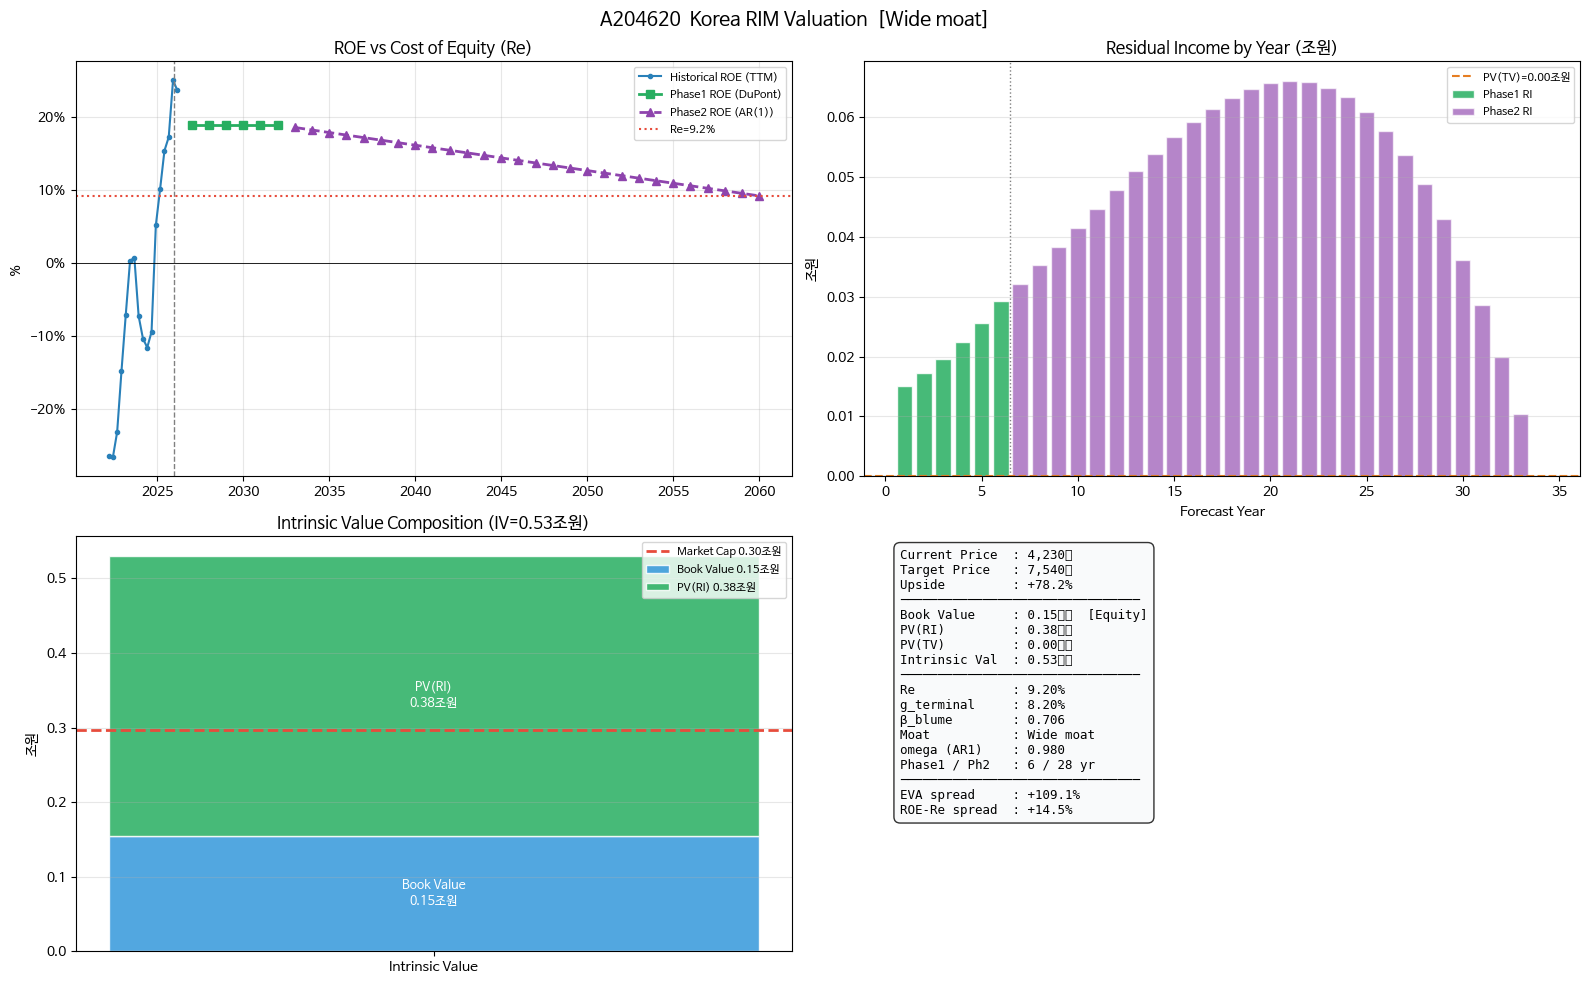

In [31]:
DIAG_TICKER = "A204620"    # ← 변경해서 분석할 종목 지정

print(f"[Diagnostics] Running KoreaRIMModel for {DIAG_TICKER} ...")
_rm = KoreaRIMModel(ticker=DIAG_TICKER, engine=engine, db_info=db_info,
                    rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX, verbose=True)
_rm.run()

v = _rm.valuation
df = _rm.result_df.copy()

SEP = "=" * 70
print(f"\n{SEP}")
print(f"  {DIAG_TICKER}  Korea RIM Diagnostics")
print(SEP)

# [1] Cost of Equity 분해
print(f"\n[1] Cost of Equity")
print(f"    Rf              : {RF*100:.3f}%  (BOK 10Y 국고채)")
print(f"    ERP             : {ERP*100:.3f}%  (method={ERP_METHOD})")
print(f"    β_raw           : {v['beta_raw']:.3f}" if not np.isnan(v['beta_raw']) else "    β_raw : fallback 1.0")
print(f"    β_blume         : {v['beta_blume']:.3f}  (= 0.67×|β| + 0.33)")
print(f"    Re = Rf + β_blume × ERP  =  {v['re']*100:.3f}%")
print(f"    clip 범위       : ★ v2 비활성 (FCFF 와 일관)")
print(f"    g_terminal      : {v['g_terminal']*100:.2f}%")
print(f"    Re - g          : {(v['re']-v['g_terminal'])*100:.3f}%")

# [2] Phase 1 DuPont
ph1_all = df[df["phase"].str.startswith("ph1")]
ph1_fc  = df[df["phase"] == "ph1"]
ph1_ext = df[df["phase"] == "ph1e"]
print(f"\n[2] Phase 1 — DuPont ROE  "
      f"[실제 예측 {len(ph1_fc)}yr + plateau 연장 {len(ph1_ext)}yr = 총 {len(ph1_all)}yr]")
for _, row in ph1_all.iterrows():
    tag = "" if row["phase"] == "ph1" else " [plateau]"
    bv_u = row["bv_start"] / 1e12
    ri_u = row["ri"] / 1e12
    print(f"    Year {int(row['year'])}{tag}  "
          f"Sales={row['sales_annual']/1e12:.2f}조  "
          f"NPM={row['npm']*100:.1f}%  AT={row['at']:.2f}  FL={row['fl']:.1f}  "
          f"ROE={row['roe']*100:.1f}%  BV={bv_u:.2f}조  RI={ri_u:+.3f}조")

# [3] Phase 2 AR(1)
print(f"\n[3] Phase 2 — AR(1) RI Decay  (ω={v['omega']:.3f}, {v['n_phase2']}yr)")
ph2 = df[df["phase"] == "ph2"]
for _, row in ph2.iterrows():
    ri_u = row["ri"] / 1e12
    bv_u = row["bv_start"] / 1e12
    print(f"    Year {int(row['year'])}  "
          f"RI={ri_u:+.3f}조  ROE_impl={row['roe']*100:.1f}%  "
          f"spread={row['ri_spread']*100:+.1f}%  BV={bv_u:.2f}조")

# [4] TV
print(f"\n[4] Terminal Value")
ri_last_u = _rm._ri_last / 1e12
tv_u = v["terminal_value"] / 1e12
pv_tv_u = v["pv_tv"] / 1e12
print(f"    RI_last          : {ri_last_u:+.3f}조")
print(f"    TV = RI_last×(1+g)/(Re-g) = {tv_u:.3f}조" if v["terminal_value"] > 0 else "    TV = 0 (RI_last ≤ 0)")
print(f"    PV(TV)           : {pv_tv_u:.3f}조")

# [5] Value Breakdown
print(f"\n[5] Value Breakdown")
iv_u = v["intrinsic_value"] / 1e12
bv0_u = v["bv0"] / 1e12
pv_ri_u = v["pv_ri"] / 1e12
bv_wt = bv0_u / iv_u * 100 if iv_u else np.nan
ri_wt = pv_ri_u / iv_u * 100 if iv_u else np.nan
tv_wt = pv_tv_u / iv_u * 100 if iv_u else np.nan
print(f"    Book Value      : {bv0_u:>7.3f}조 ({bv_wt:>5.1f}%)  [{v['bv_source']}]")
print(f"    PV(RI)          : {pv_ri_u:>7.3f}조 ({ri_wt:>5.1f}%)")
print(f"    PV(TV)          : {pv_tv_u:>7.3f}조 ({tv_wt:>5.1f}%)")
print(f"    ─────────────────────────────────")
print(f"    Intrinsic Value : {iv_u:>7.3f}조")

# [6] Target Price
print(f"\n[6] Target Price")
tp_s = f"{v['target_price']:,.0f}원" if not np.isnan(v["target_price"]) else "N/A"
cp_s = f"{v['current_price']:,.0f}원" if not np.isnan(v["current_price"]) else "N/A"
up_s = f"{v['upside_pct']:+.1f}%" if not np.isnan(v["upside_pct"]) else "N/A"
sh_s = f"{v['shares']:,.0f}주" if not np.isnan(v["shares"]) else "N/A"
print(f"    Shares          : {sh_s}")
print(f"    TP = IV / shares = {tp_s}")
print(f"    Current Price   : {cp_s}")
print(f"    Upside          : {up_s}")

# [7] EVA / Moat
print(f"\n[7] EVA / Moat 분류 (6-Tier)")
evs = v["eva_spread"]
rrs = v["roe_re_spread"]
print(f"    EVA spread      : {evs*100:+.2f}%" if not np.isnan(evs) else "    EVA : N/A")
print(f"    ROE-Re spread   : {rrs*100:+.2f}%" if not np.isnan(rrs) else "    ROE-Re : N/A")
print(f"    Moat grade      : {v['moat_label']}")
print(f"    omega (AR1)     : {v['omega']:.3f}")
print(f"    Phase1 period   : {v['n_phase1']} yr  (기본 2yr + {PHASE1_EXTRA_YR.get(v['moat_label'],1)}yr plateau)")
print(f"    Phase2 period   : {v['n_phase2']} yr")

# [8] 데이터 품질
print(f"\n[8] 데이터 품질")
print(_rm.report.summary())
display(_rm.report.to_dataframe())

# 시각화
print(f"\n[시각화]")
_rm.plot()


## Cell 8 (★ NEW v3) · 단일 Ticker → 즉시 RIM Excel 출력

Cell 6 의 `export_rim_excel` 패치를 적용한 후, 전체 배치 없이 **단일 종목만 빠르게 8-sheet Excel 생성**.

### 사용법
```python
EXPORT_TICKER = TEST_TICKER     # default: A005930
# 다른 종목으로 출력하려면 EXPORT_TICKER = "A058470" 같이 직접 지정
```

### 출력 위치
- 윈도우: `C:\reports\{ticker}_RIM_Korea_v2.xlsx`
- 그 외: `~/reports/{ticker}_RIM_Korea_v2.xlsx`

### 사후 검증 항목
실행 후 출력에서 다음을 확인하세요:
- **적정주가** vs **현재 주가** → Upside %
- **Re** (FCFF 모형의 Re와 일치해야 함 — v2 옵션 A 통일)
- **BV₀**: BV source 가 "Equity" 면 정상, "IC_fallback" 이면 음수 BV 종목
- **Moat 등급**: 6-tier 중 어느 등급으로 분류됐는지
- **EVA Spread / ROE-Re Spread**: 둘 중 하나라도 양수면 가치 창출 종목

### Δ = 0 검증 (Excel 파일 열기 후)
1. `RIM_Valuation` 시트 → B35 (Δ Excel TP − model TP) = **0원** 확인
2. `Cost_of_Equity` 시트 → B26 (Δ Excel Re vs model Re) ≈ 0 확인 (Beta 회귀가 정상이면)
3. `RI_Schedule` 시트 → 마지막 Δ (Excel SUM − model pv_ri) = 0 확인

### Cell 7 (배치) 와의 관계
Cell 7 batch 는 DB 저장만, Excel 출력은 안 함. **Excel 은 단일 종목만 (Cell 8)** 또는 별도 batch loop 작성 시 가능.


In [32]:
# ═══════════════════════════════════════════════════════════════
#  Cell 8 (★ NEW v3) · 단일 Ticker → 즉시 RIM Excel 출력
# ═══════════════════════════════════════════════════════════════
#  Cell 6 의 export_rim_excel patch 를 적용한 후 실행.
#  전체 배치 없이 단일 종목만 빠르게 8-sheet Excel 생성.
# ═══════════════════════════════════════════════════════════════

# ── 분석할 ticker (★ 변경 시 이 줄만 수정) ───────────
EXPORT_TICKER = "A003350"    # Cell 5 의 TEST_TICKER 또는 직접 지정 (e.g. "A058470")
# ════════════════════════════════════════════════════════════

# ── 출력 경로 ─────────────────────────────────────────────
EXPORT_DIR = (Path(r"C:/reports") if os.name == "nt"
              else Path.home() / "reports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n{'='*70}")
print(f"[Single Export RIM] {EXPORT_TICKER} → 8-sheet Excel (RIM v2 / Excel v3)")
print(f"{'='*70}")

# ── 사전 검증 ────────────────────────────────────────────
assert hasattr(KoreaRIMModel, "export_rim_excel"), \
    "KoreaRIMModel.export_rim_excel 없음 — Cell 6 패치 셀을 먼저 실행하세요."

# ── 실행 ─────────────────────────────────────────────────
_model = KoreaRIMModel(
    ticker=EXPORT_TICKER, engine=engine, db_info=db_info,
    rf=RF, e_rm=E_RM, kospi_series=KOSPI_PX,
    verbose=True,
)
try:
    _model.run()
    _path = _model.export_rim_excel(out_dir=EXPORT_DIR)
    v = _model.valuation
    print(f"\n  ✓ Saved: {_path}")
    tp_str = f"{v['target_price']:,.0f}원" if not np.isnan(v['target_price']) else "N/A"
    cp_str = f"{v['current_price']:,.0f}원" if not np.isnan(v['current_price']) else "N/A"
    up_str = f"{v['upside_pct']:+.1f}%" if not np.isnan(v['upside_pct']) else "N/A"
    print(f"    적정주가     : {tp_str}")
    print(f"    현재 주가    : {cp_str}")
    print(f"    Upside       : {up_str}")
    print(f"    Re           : {v['re']*100:.2f}%")
    print(f"    BV₀          : {v['bv0']/1e12:.2f}조  ({v['bv_source']})")
    print(f"    Σ PV(RI)     : {v['pv_ri']/1e12:.2f}조")
    print(f"    PV(TV)       : {v['pv_tv']/1e12:.2f}조  (TV weight={v['tv_weight_pct']:.1f}%)")
    print(f"    Moat         : {v['moat_label']}  "
          f"(ω={v['omega']:.3f}, Phase1={v['n_phase1']}yr, Phase2={v['n_phase2']}yr)")
    print(f"    g_term       : {v['g_terminal']*100:.2f}%")
    print(f"    EVA Spread   : {v.get('eva_spread', np.nan)*100:+.1f}%")
    print(f"    ROE-Re       : {v.get('roe_re_spread', np.nan)*100:+.1f}%" if not np.isnan(v.get('roe_re_spread', np.nan)) else "    ROE-Re       : N/A")
except Exception as e:
    print(f"\n  ✗ FAIL: {e}")
    import traceback
    traceback.print_exc()



[Single Export RIM] A003350 → 8-sheet Excel (RIM v2 / Excel v3)
[18:36:50][A003350] Sales actual=66Q forecast=8Q (Ensemble)
[18:36:50][A003350] FS wide shape=(67, 35)
[18:36:53][A003350] Re=10.0324%  β_raw=0.738 β_blume=0.824  Rf=4.261% ERP=7.000%
[18:36:53][A003350] DuPont  NPM=0.1927(ols)  AT=0.909(TTM)  FL=1.52
[18:36:57][A003350] EVA: ROIC=53.74% WACC=7.78% spread=+45.96% n_pos=15/20  ROE-Re=+19.6%
[18:36:57][A003350] Retention=0.914  payout=0.086
[18:36:57][A003350] Retention=0.914  payout=0.086
[18:36:57][A003350] RI path(LINEAR-fade v5): Ph1=6yr Ph2=28yr  spread 17.7%→0  b 0.75→0.40  RI_last=0.0B(=0 기대) → TV=0  [Wide moat]
[18:37:00][A003350] RIM  BV=0.11조 PV(RI)=0.79조 PV(TV)=0.00조 IV=0.90조  TP=49,512원 CP=7,920원 Up=+525.1%  [Wide moat]
[18:37:00][A003350] 종목 월별 종가 fetch fail: (1054, "Unknown column 'close_price' in 'field list'")
[18:37:00][A003350] DuPont  NPM=0.1927(ols)  AT=0.909(TTM)  FL=1.52
[18:37:00][A003350] Excel saved: C:\reports\A003350_RIM_Korea_v2.xlsx

  ✓ Saved: 

## Cell 9 · 배치 실행

In [12]:
RUN_TICKERS = KOREA_TICKER_LIST[TICKER_START:TICKER_END]
total = len(RUN_TICKERS)
run_date = datetime.now().strftime("%Y-%m-%d")

done_set = set()
if SKIP_DONE and os.path.exists(DONE_PATH):
    with open(DONE_PATH, encoding="utf-8") as f:
        done_set = {l.strip() for l in f if l.strip()}

ok_cnt = skip_cnt = fail_cnt = 0
results, all_reports = [], []
t0 = time.time()

log("BATCH", f"RIM 배치 시작: {total:,}개  run_date={run_date}")
print("=" * 80)

for idx, ticker in enumerate(RUN_TICKERS, 1):
    pct = idx / total * 100
    prefix = f"[{idx:>5}/{total}] ({pct:5.1f}%) {ticker:<8}"

    if SKIP_DONE and ticker in done_set:
        print(f"{prefix} SKIP", flush=True); skip_cnt += 1; continue

    res = process_one_ticker_rim_kr(
        ticker, engine, db_info, RF, E_RM, KOSPI_PX,
        verbose=False, run_date=run_date, save_db=True)
    results.append(res)
    if res["report"] is not None:
        all_reports.append(res["report"])

    if res["status"] == "ok":
        tp = res["target_price"]; up = res["upside_pct"]
        tp_s = f"TP={tp:,.0f}원" if not np.isnan(tp) else "TP=N/A"
        up_s = f"↑{up:+.1f}%" if not np.isnan(up) else ""
        print(f"{prefix} OK  {tp_s} {up_s}  Re={res['re']:.3%}  [{res['moat_label']}] ω={res['omega']:.2f}", flush=True)
        with open(DONE_PATH, "a", encoding="utf-8") as f:
            f.write(ticker + "\n")
        ok_cnt += 1
    else:
        print(f"{prefix} FAIL  {res.get('msg','')}", flush=True)
        with open(FAIL_PATH, "a", encoding="utf-8") as f:
            f.write(f"{ticker}\t{res.get('msg','')}\n")
        fail_cnt += 1

elapsed = time.time() - t0
print("=" * 80)
log("BATCH", f"완료  OK={ok_cnt}  SKIP={skip_cnt}  FAIL={fail_cnt}  "
             f"경과={elapsed:.0f}s  평균={elapsed/max(ok_cnt+fail_cnt,1):.1f}s/ticker")

# 품질 로그 저장
if all_reports:
    n_q = save_quality_report_to_db(
        all_reports, db_info, table_name=TABLE_QUALITY,
        run_date=run_date, model_name="RIM")
    log("QUALITY", f"품질 로그 {n_q:,}건 → {TABLE_QUALITY}")

# 요약
if results:
    summary = pd.DataFrame([{
        "ticker": r["ticker"], "re": r["re"],
        "moat": r["moat_label"], "omega": r["omega"],
        "tp": r["target_price"], "cp": r["current_price"],
        "upside": r["upside_pct"], "bv_src": r["bv_source"],
        "status": r["status"],
    } for r in results])
    ok_summary = summary[summary["status"] == "ok"].sort_values("upside", ascending=False)
    print("\n[상위 업사이드 TOP 20]")
    display(ok_summary.head(20))


[17:17:48][BATCH] RIM 배치 시작: 1,277개  run_date=2026-06-12
[    1/1277] (  0.1%) A069730  OK  TP=14,859원 ↑+180.9%  Re=10.376%  [Some moat] ω=0.94
[    2/1277] (  0.2%) A071950  OK  TP=1,677원 ↑-19.6%  Re=10.671%  [No moat] ω=0.88
[    3/1277] (  0.2%) A074610  OK  TP=-118원 ↑-102.3%  Re=10.685%  [No moat] ω=0.88
[    4/1277] (  0.3%) A077500  OK  TP=8,553원 ↑+7.0%  Re=11.945%  [Some moat] ω=0.94
[    5/1277] (  0.4%) A079430  OK  TP=12,586원 ↑+95.1%  Re=9.902%  [No moat] ω=0.88
[    6/1277] (  0.5%) A084010  OK  TP=19,883원 ↑+126.5%  Re=9.587%  [No moat] ω=0.88
[    7/1277] (  0.5%) A084680  OK  TP=732원 ↑-42.3%  Re=10.231%  [No moat] ω=0.88
[    8/1277] (  0.6%) A092440  OK  TP=6,634원 ↑+238.6%  Re=8.461%  [No moat] ω=0.88
[    9/1277] (  0.7%) A105630  OK  TP=19,489원 ↑+124.3%  Re=9.911%  [No moat] ω=0.88
[   10/1277] (  0.8%) A109070  OK  TP=458원 ↑-69.5%  Re=8.204%  [Some moat] ω=0.94
[   11/1277] (  0.9%) A000020  OK  TP=10,797원 ↑+102.6%  Re=9.210%  [No moat] ω=0.88
[   12/1277] (  0.9%) A00

,ticker,re,moat,omega,tp,cp,upside,bv_src,status
484,A005110,0.094185,Wide moat,0.98,7.786157e+11,1254.0,6.209057e+10,Equity,ok
683,A272450,0.103219,Wide moat,0.98,3.609454e+08,5510.0,6.550632e+06,Equity,ok
1206,A043260,0.119301,Wide-Narrow moat,0.97,3.555318e+07,46650.0,7.611260e+04,Equity,ok
71,A008500,0.078293,Narrow moat,0.95,4.032656e+04,806.0,4.903295e+03,Equity,ok
695,A298690,0.097911,No moat,0.88,7.193613e+04,1647.0,4.267707e+03,Equity,ok
1146,A123330,0.098720,Wide moat,0.98,9.509997e+05,22250.0,4.174156e+03,Equity,ok
257,A019180,0.110422,Wide-Narrow moat,0.97,2.670266e+05,7210.0,3.603559e+03,Equity,ok
802,A026150,0.108768,No moat,0.88,1.066751e+05,4300.0,2.380816e+03,Equity,ok
116,A031820,0.154730,Narrow moat,0.95,1.508480e+05,6110.0,2.368870e+03,Equity,ok
1201,A040300,0.090210,No moat,0.88,4.847973e+04,2340.0,1.971783e+03,Equity,ok


## Cell 10 · 결과 조회 & 시각화

In [ ]:
# ── 7-1. DB 현황 ──────────────────────────────────────
conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(f"""
            SELECT DATE(date) AS run_date,
                   COUNT(DISTINCT ticker) AS tickers,
                   COUNT(*) AS total_rows,
                   AVG(target_price) AS avg_tp,
                   AVG(upside_pct) AS avg_upside,
                   AVG(re) AS avg_re
            FROM {TABLE_RESULT}
            GROUP BY DATE(date)
            ORDER BY run_date DESC LIMIT 10
        """)
        summary_df = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 70); print(f"[DB 현황] {TABLE_RESULT}"); print("=" * 70)
display(summary_df)

# ── 7-2. 최신 평가일 결과 ─────────────────────────────
conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        cur.execute(f"SELECT MAX(date) AS m FROM {TABLE_RESULT}")
        max_date = cur.fetchone()["m"]
        if max_date:
            cur.execute(f"""
                SELECT ticker,
                       MAX(target_price) AS target_price,
                       MAX(current_price) AS current_price,
                       MAX(upside_pct) AS upside_pct,
                       MAX(re) AS re,
                       MAX(rho) AS omega,
                       MAX(n_phase2) AS n_phase2,
                       MAX(moat_label) AS moat,
                       MAX(bv_source) AS bv_source,
                       MAX(intrinsic_value) AS intrinsic_value
                FROM {TABLE_RESULT}
                WHERE date = %s
                  AND target_price IS NOT NULL
                  AND current_price IS NOT NULL
                GROUP BY ticker
                ORDER BY upside_pct DESC
            """, (max_date,))
            results_df = pd.DataFrame(cur.fetchall())
        else:
            results_df = pd.DataFrame()
finally:
    conn.close()

if not results_df.empty:
    print(f"\n[최신 평가일: {max_date}] 총 {len(results_df):,}개")
    print("\n🔼 업사이드 TOP 20"); display(results_df.head(20))
    print("\n🔽 다운사이드 TOP 20"); display(results_df.tail(20))

    # 시각화
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Korea RIM Valuation Summary ({max_date})", fontsize=13)

    ax = axes[0]
    upside_clean = results_df["upside_pct"].dropna().clip(-200, 200)
    ax.hist(upside_clean, bins=40, color="#3498db", edgecolor="white", alpha=0.8)
    ax.axvline(0, color="black", lw=1)
    ax.axvline(20, color="green", lw=1, ls="--", label="+20%")
    ax.set_title("Upside Distribution")
    ax.set_xlabel("Upside (%)"); ax.legend(); ax.grid(alpha=0.3)

    ax = axes[1]
    grade = pd.cut(results_df["upside_pct"],
                   bins=[-np.inf, -20, 0, 20, 50, np.inf],
                   labels=["Strong Sell", "Sell", "Hold", "Buy", "Strong Buy"])
    grade.value_counts().sort_index().plot(
        kind="barh", ax=ax,
        color=["#c0392b", "#e74c3c", "#f39c12", "#2ecc71", "#27ae60"])
    ax.set_title("Valuation Grade"); ax.grid(axis="x", alpha=0.3)

    ax = axes[2]
    moat_cnts = results_df["moat"].value_counts()
    colors_moat = {
        "Exceptional moat": "#27ae60", "Wide moat": "#2ecc71",
        "Wide-Narrow moat": "#f1c40f", "Narrow moat": "#f39c12",
        "Some moat": "#e67e22", "No moat": "#c0392b",
        "Unknown (fallback)": "#95a5a6",
    }
    bar_colors = [colors_moat.get(m, "#95a5a6") for m in moat_cnts.index]
    ax.barh(range(len(moat_cnts)), moat_cnts.values, color=bar_colors, alpha=0.85)
    ax.set_yticks(range(len(moat_cnts)))
    ax.set_yticklabels(moat_cnts.index, fontsize=9)
    ax.set_title("Moat Distribution"); ax.grid(axis="x", alpha=0.3)

    plt.tight_layout(); plt.show()
else:
    print("[INFO] 데이터 없음 — Cell 6 배치 실행 필요")

# ── 7-3. 종목별 RIM 평가 이력 ─────────────────────────
def get_rim_history(ticker, db_info, table_name=TABLE_RESULT):
    tk = to_dg_ticker(ticker)
    sql = f"""
        SELECT date,
               MAX(target_price) AS target_price,
               MAX(current_price) AS current_price,
               MAX(upside_pct) AS upside_pct,
               MAX(re) AS re,
               MAX(moat_label) AS moat,
               MAX(intrinsic_value) AS iv
        FROM `{table_name}`
        WHERE ticker = %s
        GROUP BY date
        ORDER BY date DESC
    """
    conn = get_pymysql_conn(db_info)
    try:
        with conn.cursor() as cur:
            cur.execute(sql, (tk,))
            return pd.DataFrame(cur.fetchall())
    finally:
        conn.close()

print("\n[예시] 삼성전자 RIM 평가 이력")
display(get_rim_history("A005930", db_info))


## Cell 11 · 데이터 품질 진단 (호영님 결정 #5)

배치 실행 시 모든 fallback 내역이 `korea_valuation_quality_log` 에 저장됩니다. 이 셀에서 어떤 종목의 어떤 항목이 어떤 이유로 fallback 되었는지 확인할 수 있습니다.


In [ ]:
conn = get_pymysql_conn(db_info)
try:
    with conn.cursor() as cur:
        # [1] 항목별 status 분포
        cur.execute(f"""
            SELECT field, status, COUNT(*) AS cnt,
                   AVG(r_squared) AS avg_r2, AVG(value) AS avg_value
            FROM {TABLE_QUALITY}
            WHERE model='RIM'
              AND date=(SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='RIM')
            GROUP BY field, status
            ORDER BY field, status
        """)
        df_status = pd.DataFrame(cur.fetchall())

        # [2] 항목별 fallback 비율
        cur.execute(f"""
            SELECT field,
                   SUM(status='ok') AS ok_cnt,
                   SUM(status='fallback_median') AS fb_med,
                   SUM(status='fallback_zero') AS fb_zero,
                   SUM(status='missing') AS miss,
                   COUNT(*) AS total,
                   ROUND(SUM(status LIKE 'fallback%')/COUNT(*)*100, 1) AS fb_pct
            FROM {TABLE_QUALITY}
            WHERE model='RIM'
              AND date=(SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='RIM')
            GROUP BY field
            ORDER BY fb_pct DESC
        """)
        df_field = pd.DataFrame(cur.fetchall())

        # [3] 문제 종목 TOP 30
        cur.execute(f"""
            SELECT ticker,
                   SUM(status LIKE 'fallback%') AS fb_cnt,
                   SUM(status='missing') AS miss_cnt,
                   GROUP_CONCAT(DISTINCT field ORDER BY field SEPARATOR ',') AS issues
            FROM {TABLE_QUALITY}
            WHERE model='RIM'
              AND date=(SELECT MAX(date) FROM {TABLE_QUALITY} WHERE model='RIM')
              AND (status LIKE 'fallback%' OR status='missing')
            GROUP BY ticker
            HAVING fb_cnt + miss_cnt >= 3
            ORDER BY (fb_cnt + miss_cnt*2) DESC
            LIMIT 30
        """)
        df_problem = pd.DataFrame(cur.fetchall())

        # [4] 음수 BV (IC fallback) 종목 리스트
        cur.execute(f"""
            SELECT DISTINCT ticker, MAX(intrinsic_value) AS iv,
                   MAX(target_price) AS tp, MAX(upside_pct) AS up
            FROM {TABLE_RESULT}
            WHERE bv_source = 'IC_fallback'
              AND date=(SELECT MAX(date) FROM {TABLE_RESULT})
            GROUP BY ticker
            ORDER BY upside_pct DESC
        """)
        df_ic = pd.DataFrame(cur.fetchall())
finally:
    conn.close()

print("=" * 70); print("[1] 항목별 status 분포 (최신 RIM 배치)"); print("=" * 70)
display(df_status)

print("\n" + "=" * 70); print("[2] 항목별 fallback 비율"); print("=" * 70)
display(df_field)

print("\n" + "=" * 70); print("[3] 데이터 문제가 많은 종목 TOP 30"); print("=" * 70)
display(df_problem)

print("\n" + "=" * 70); print("[4] 음수 BV → IC fallback 종목 (신뢰도 주의)"); print("=" * 70)
display(df_ic)


def inspect_rim_quality(ticker, run_date=None):
    """특정 종목의 RIM 데이터 품질 상세."""
    tk = to_dg_ticker(ticker)
    conn = get_pymysql_conn(db_info)
    try:
        with conn.cursor() as cur:
            if run_date:
                cur.execute(f"""SELECT date, field, status, n_obs, value, r_squared, note
                                  FROM {TABLE_QUALITY}
                                  WHERE ticker=%s AND date=%s AND model='RIM'
                                  ORDER BY field""", (tk, run_date))
            else:
                cur.execute(f"""SELECT date, field, status, n_obs, value, r_squared, note
                                  FROM {TABLE_QUALITY}
                                  WHERE ticker=%s AND model='RIM'
                                    AND date=(SELECT MAX(date) FROM {TABLE_QUALITY}
                                               WHERE ticker=%s AND model='RIM')
                                  ORDER BY field""", (tk, tk))
            return pd.DataFrame(cur.fetchall())
    finally:
        conn.close()

print("\n[예시] 삼성전자 RIM 품질 상세")
display(inspect_rim_quality("A005930"))
